       eventname                      pipeline         snr   width_ms  \
0   FRB20180725A         Native (CHIME portal)  311.775313   2.949120   
1   FRB20180725A               B: CHIME Boxcar  402.130911   2.949120   
2   FRB20180725A  A: Optimized Asymmetric FRED  435.745495   2.314863   
3   FRB20180727A         Native (CHIME portal)  148.256974   2.949120   
4   FRB20180727A               B: CHIME Boxcar  244.440651   3.932160   
..           ...                           ...         ...        ...   
85  FRB20181227A               B: CHIME Boxcar  349.171551  14.745599   
86  FRB20181227A  A: Optimized Asymmetric FRED  367.761705   5.671579   
87  FRB20190701D         Native (CHIME portal)  330.434750   9.830400   
88  FRB20190701D               B: CHIME Boxcar  442.838474  12.779520   
89  FRB20190701D  A: Optimized Asymmetric FRED  480.120957   2.314863   

    decay_tau_ms  equiv_width_ms  peak_time_ms  off_pulse_sigma  
0            NaN        2.981783     12.779520         9.

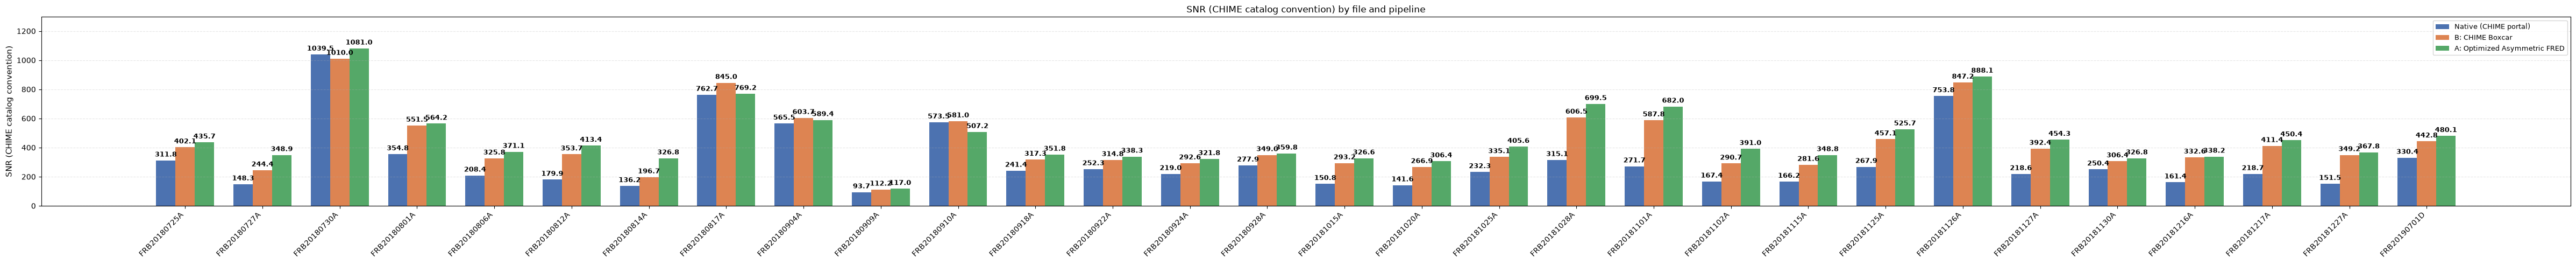

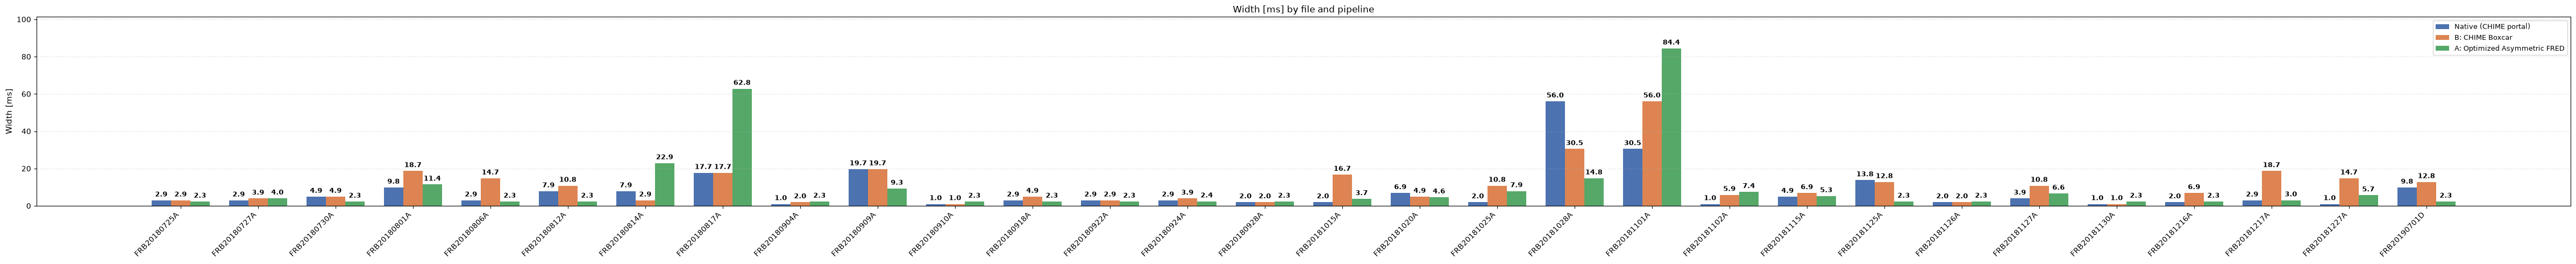

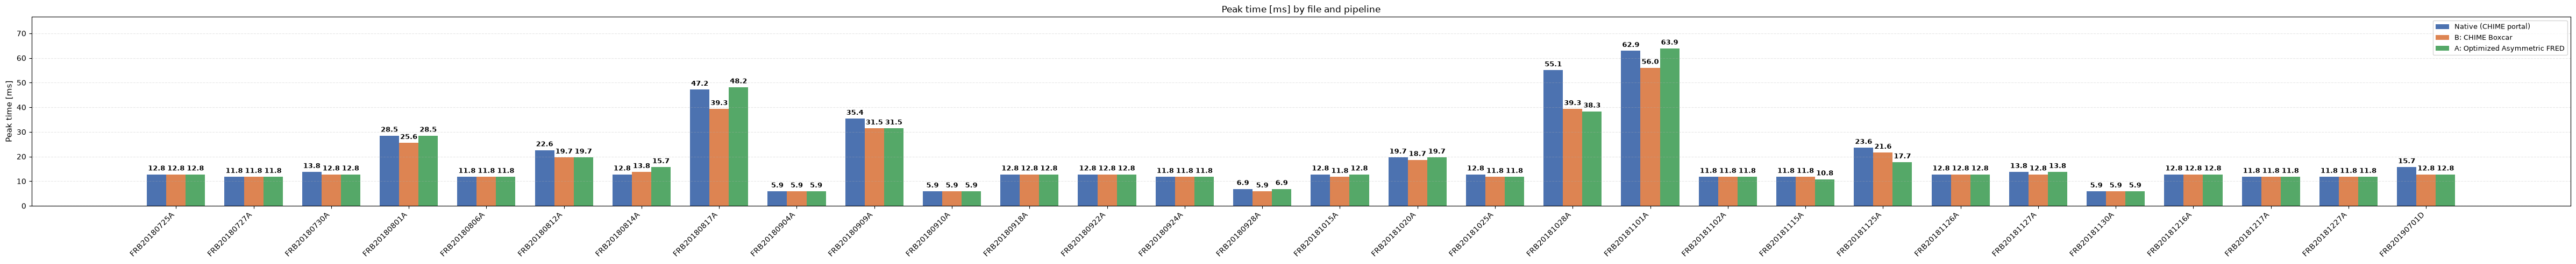

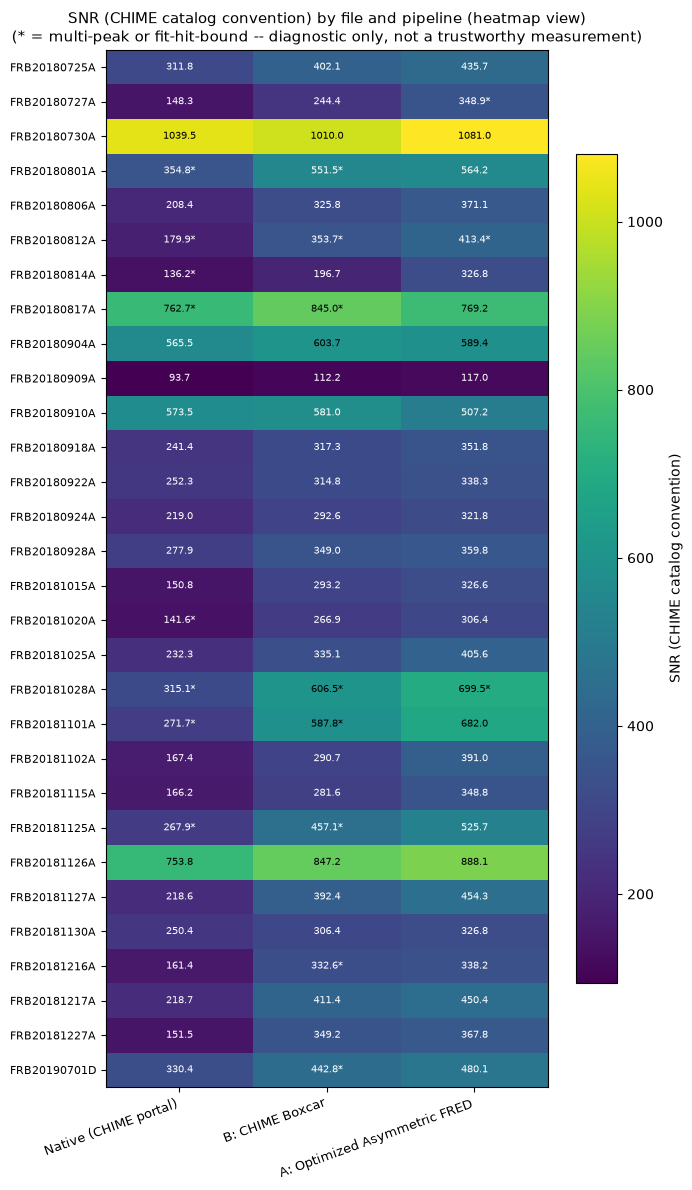

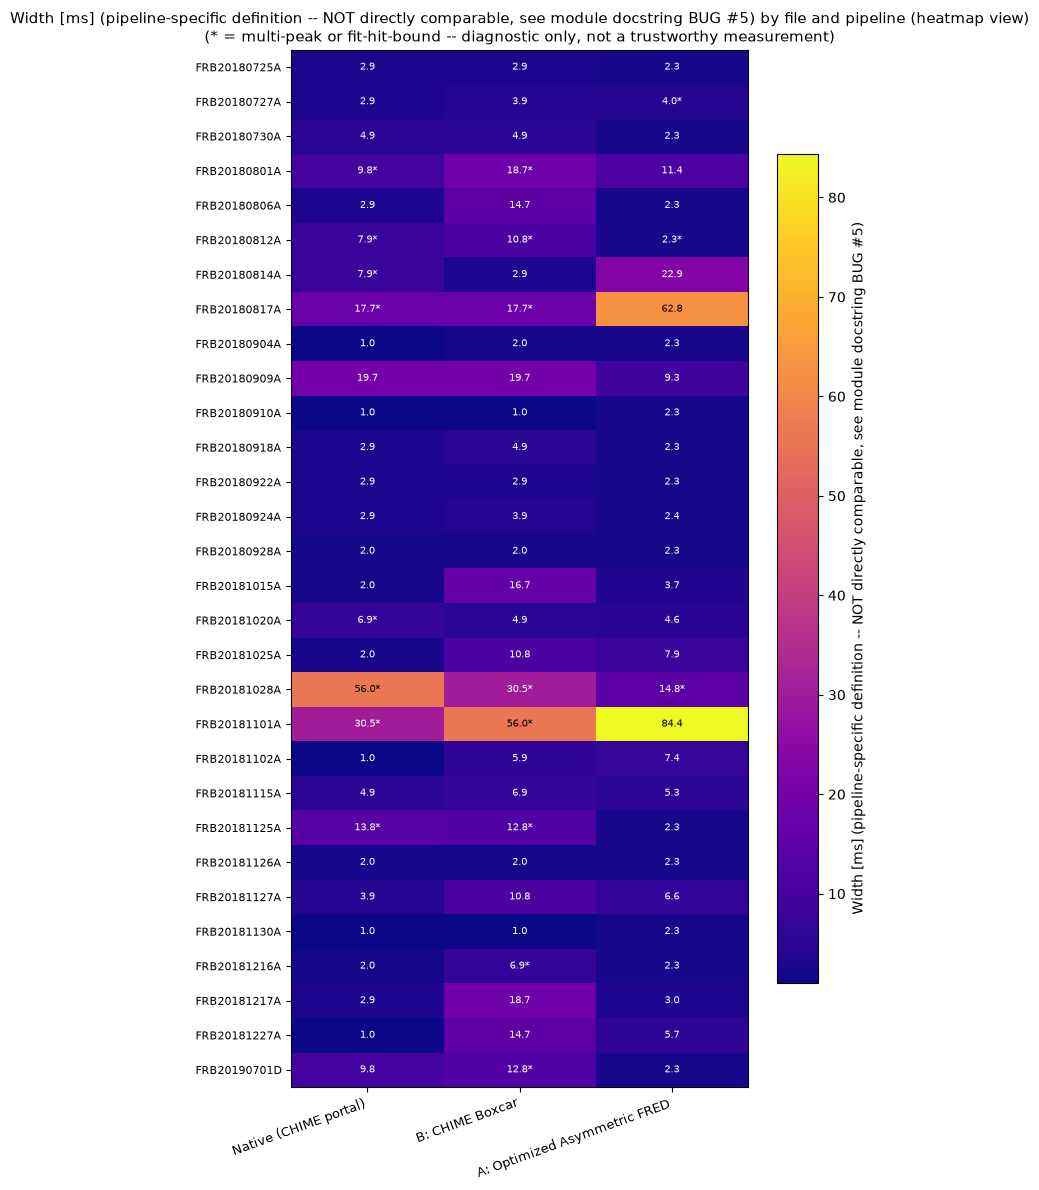

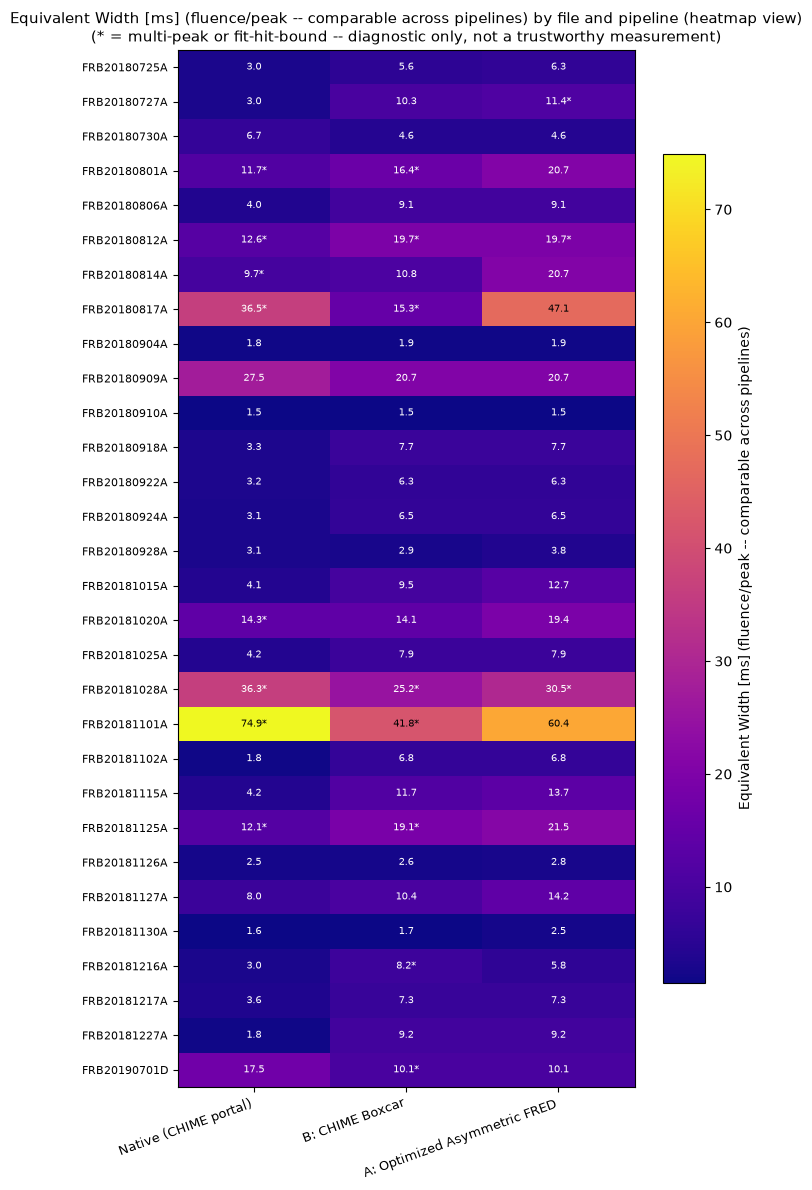

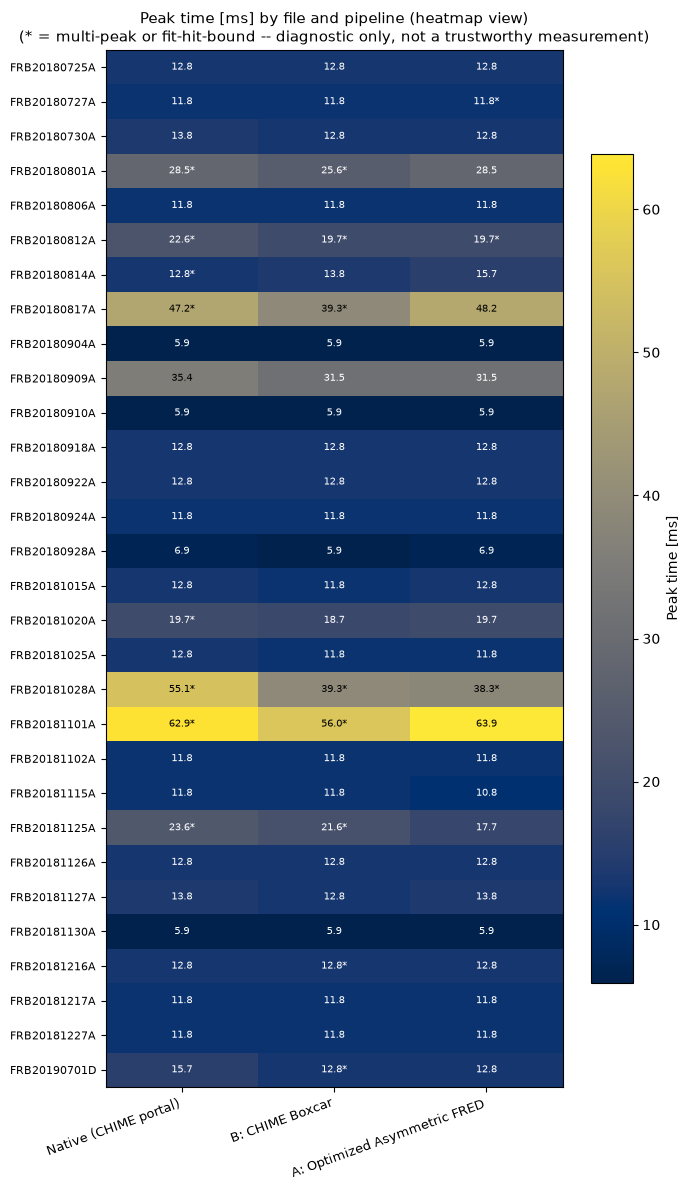

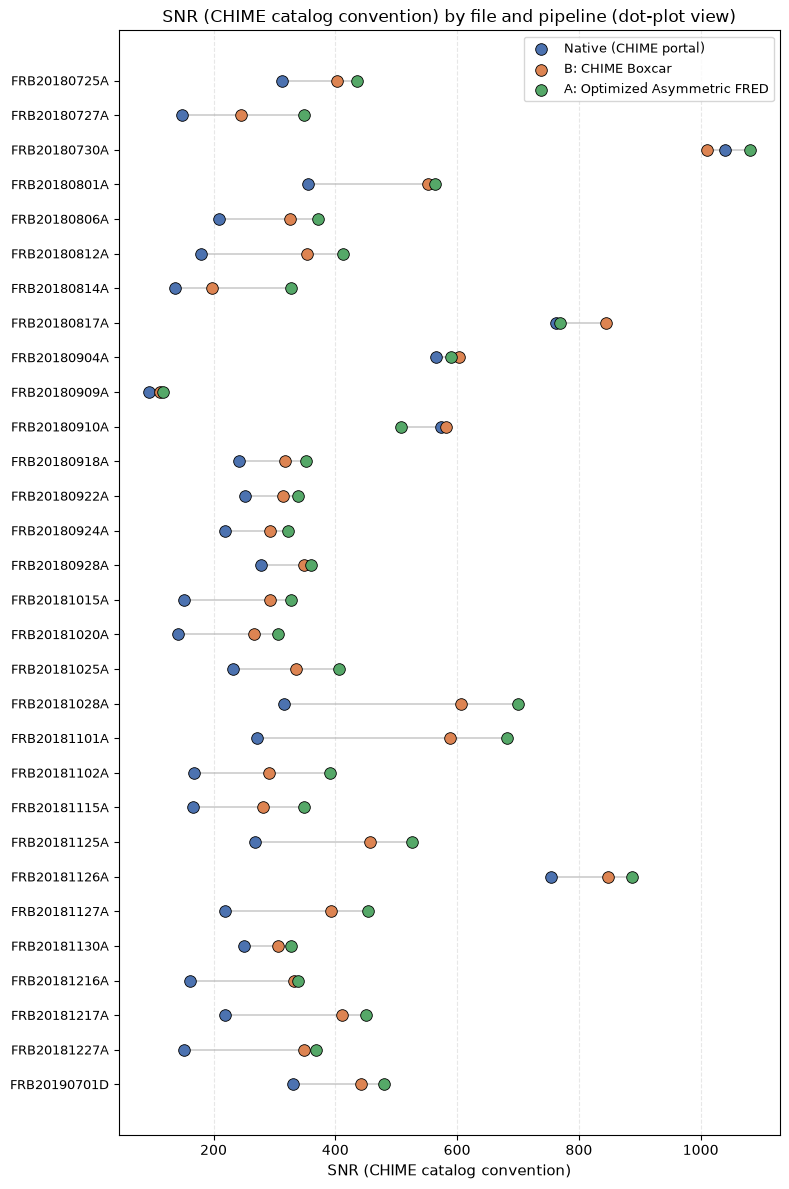

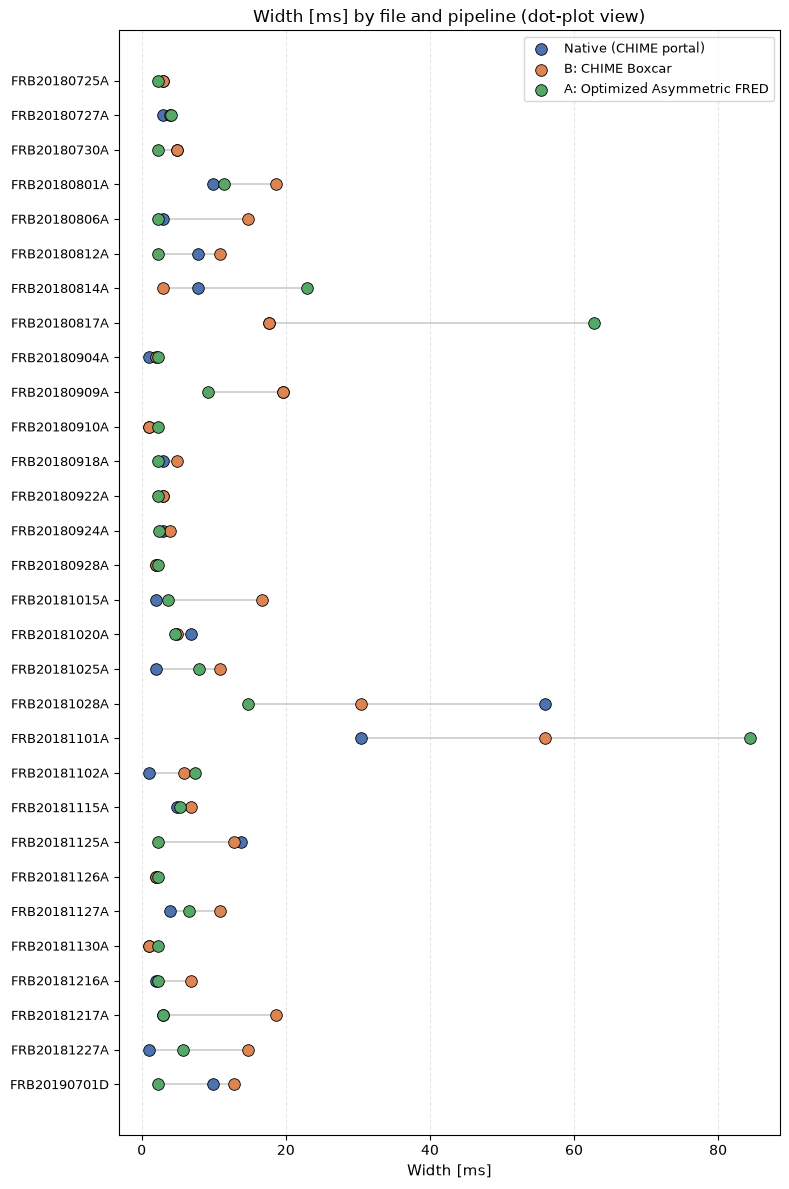

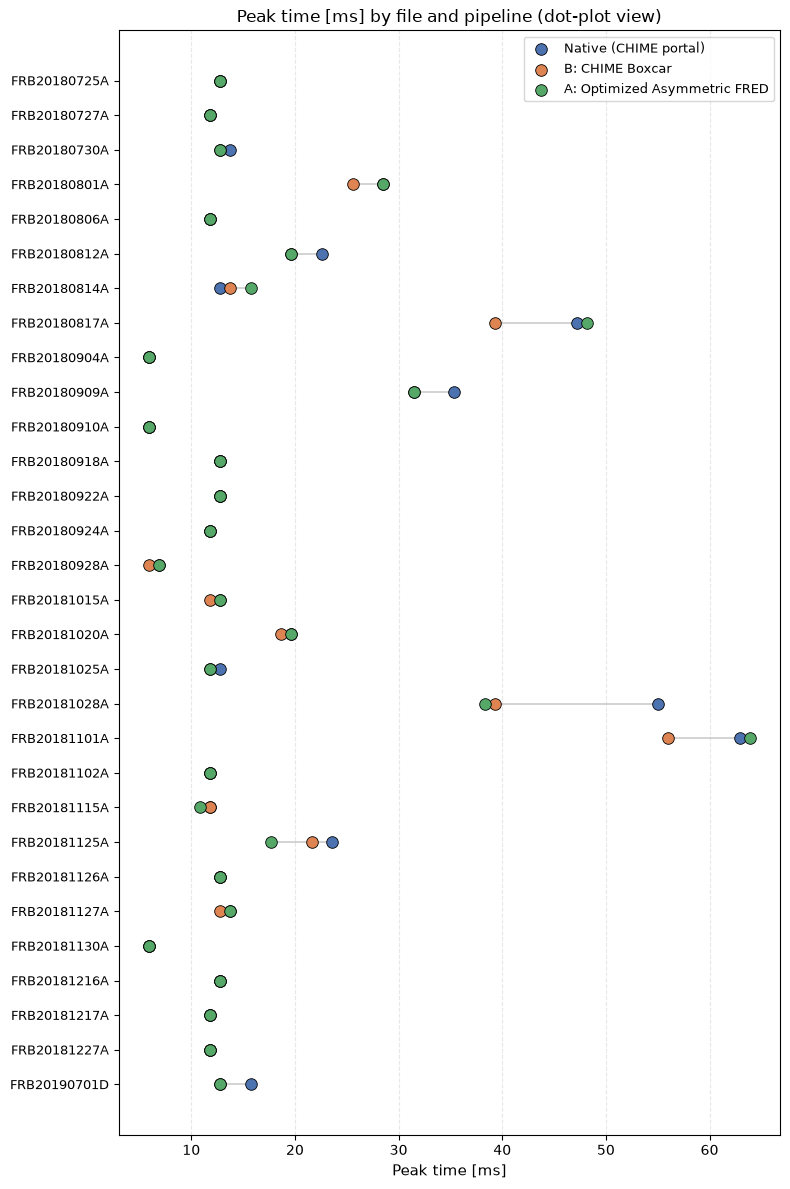


EXTENDED SNR COMPARISON
=== Per-pipeline SNR statistics ===
                    pipeline  N_events  mean_snr  median_snr  std_snr  mean_ratio_vs_native  median_ratio_vs_native
       Native (CHIME portal)        30   305.416     236.829  215.229                 1.000                   1.000
             B: CHIME Boxcar        30   423.362     349.099  199.459                 1.540                   1.499
A: Optimized Asymmetric FRED        30   462.899     398.290  193.403                 1.747                   1.764


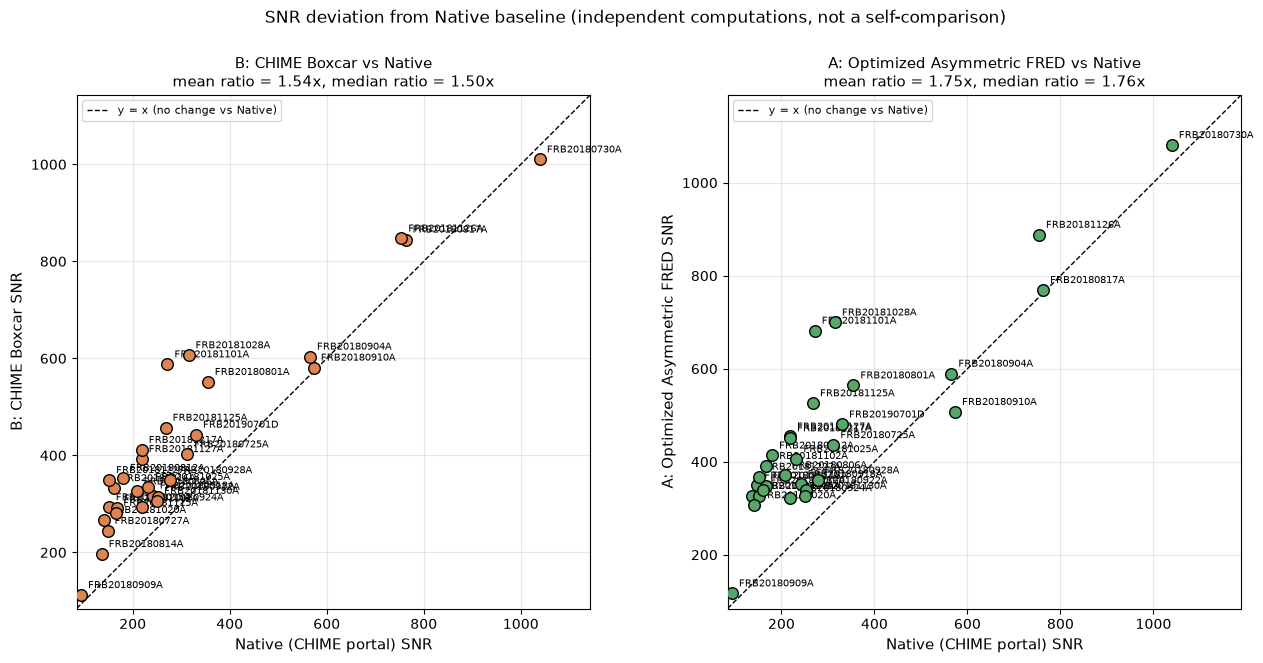

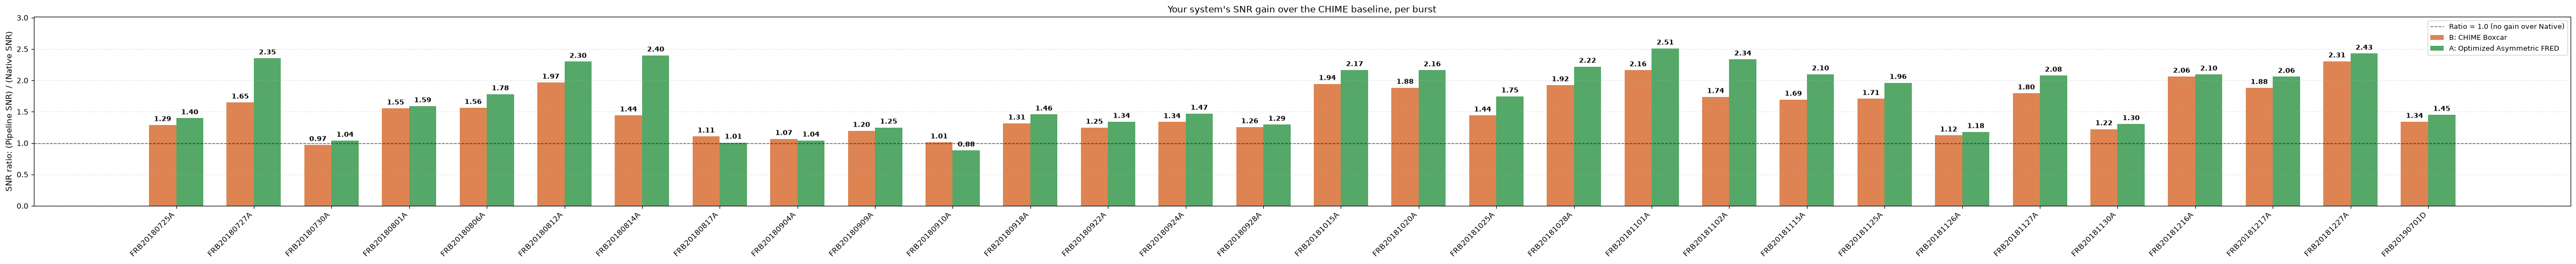


DM REFINEMENT (DM-SNR search, Method A)
FRB20180725A     DM_0=715.809 delta=-0.273 -> refined DM=715.537 (SNR=317.5)
FRB20180727A     DM_0=642.134 delta=+0.125 -> refined DM=642.259 (SNR=151.5)
FRB20180730A     DM_0=848.904 delta=-0.210 -> refined DM=848.694 (SNR=1042.3)
FRB20180801A     DM_0=655.728 delta=-0.700 -> refined DM=655.028 (SNR=361.6)
FRB20180806A     DM_0=739.948 delta=-0.004 -> refined DM=739.945 (SNR=208.4)
FRB20180812A     DM_0=802.451 delta=-0.061 -> refined DM=802.390 (SNR=180.5)
FRB20180814A     DM_0=189.286 delta=-1.589 -> refined DM=187.697 (SNR=157.4)
FRB20180817A     DM_0=1006.771 delta=-0.021 -> refined DM=1006.750 (SNR=762.7)
FRB20180904A     DM_0=361.137 delta=+0.025 -> refined DM=361.163 (SNR=565.5)
FRB20180909A     DM_0=408.647 delta=-0.050 -> refined DM=408.597 (SNR=93.7)
FRB20180910A     DM_0=684.408 delta=-0.010 -> refined DM=684.398 (SNR=573.5)
FRB20180918A     DM_0=1453.988 delta=-0.123 -> refined DM=1453.865 (SNR=260.1)
FRB20180922A     DM_0=555.687 d

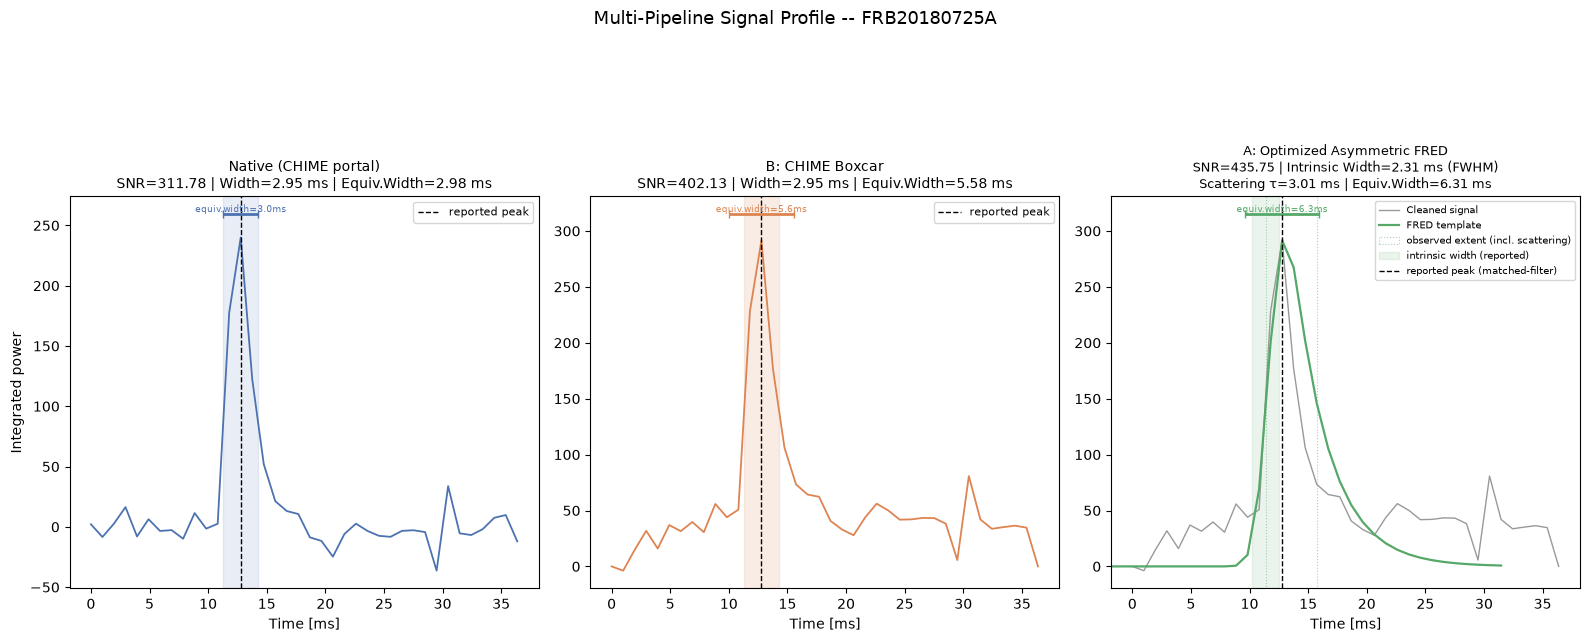

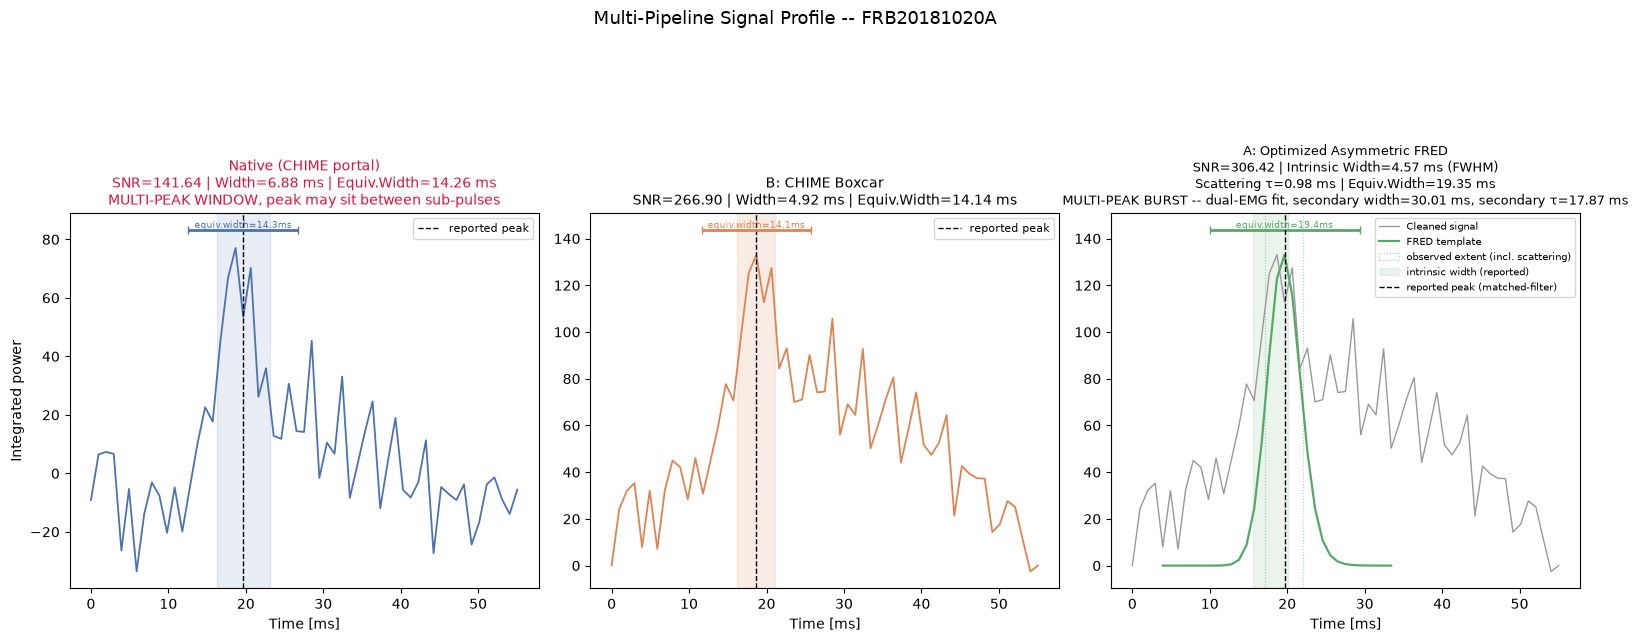

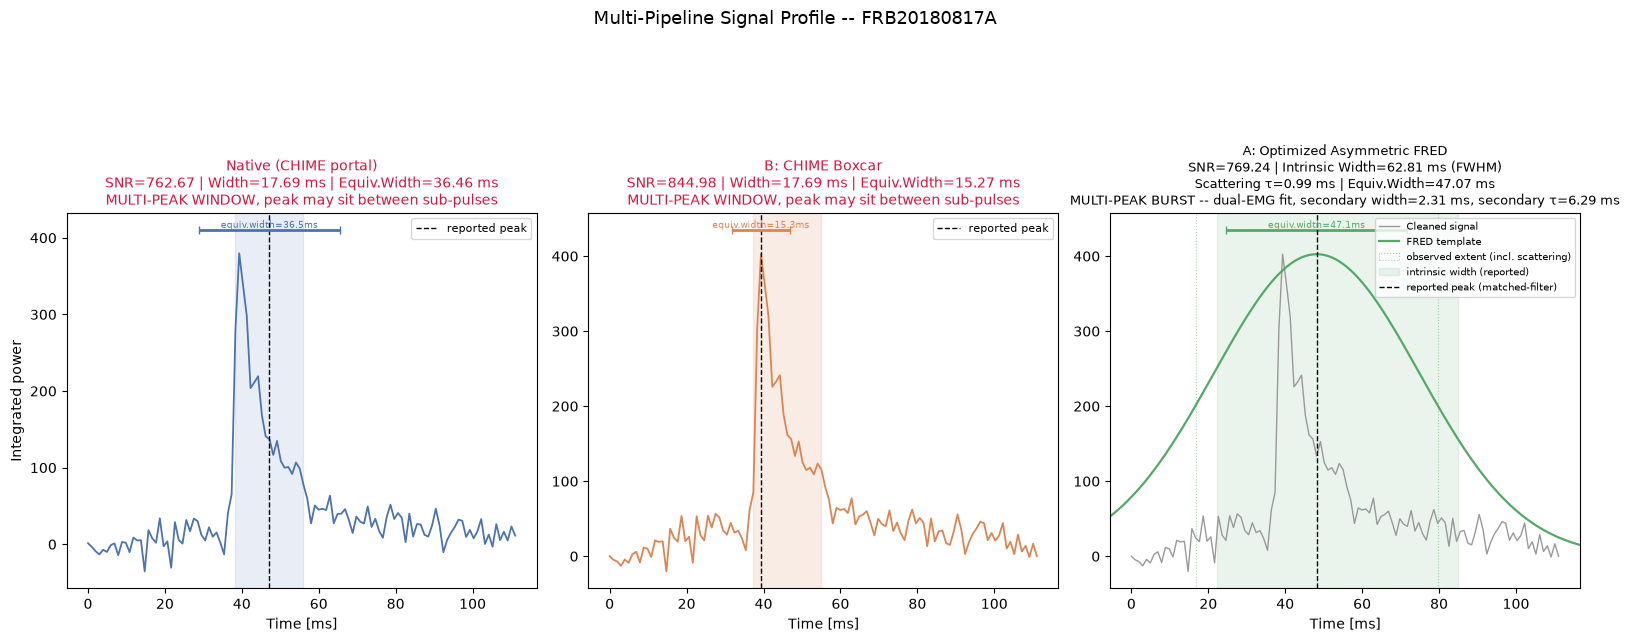

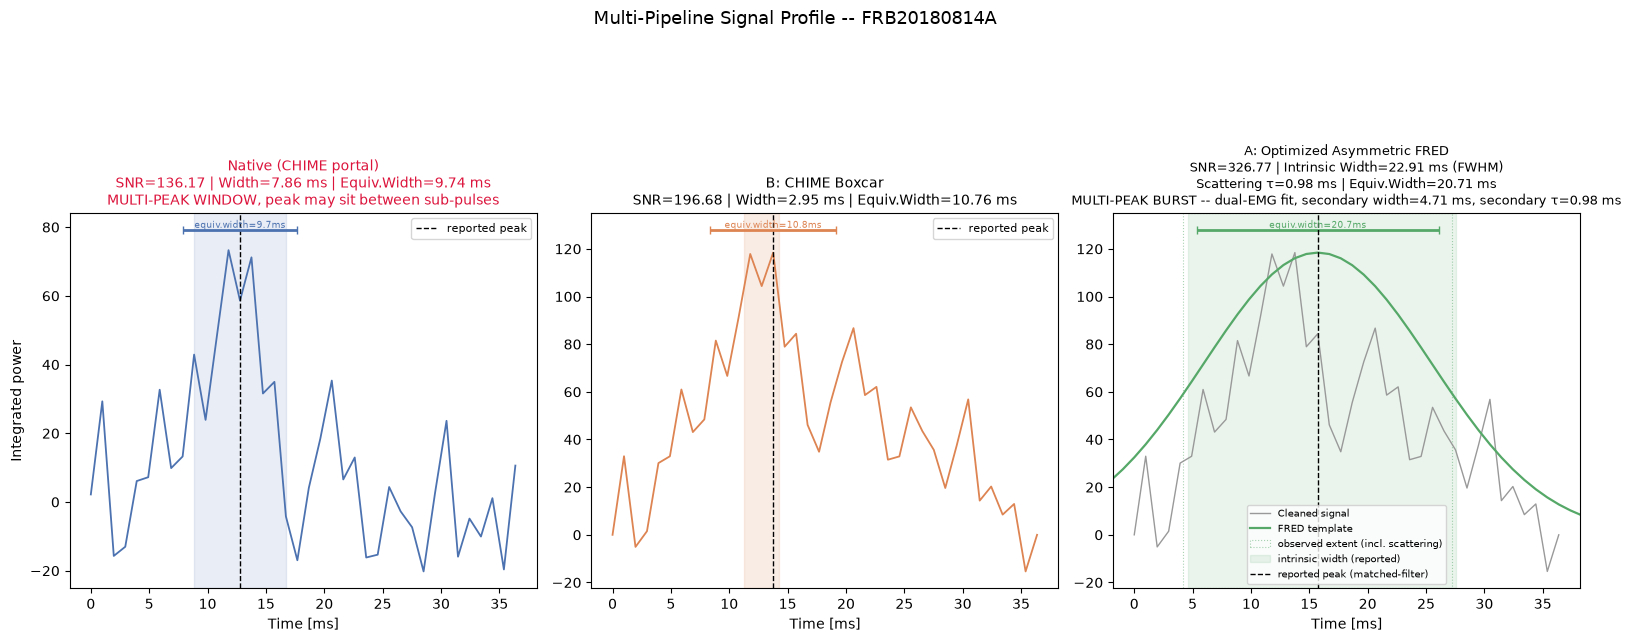

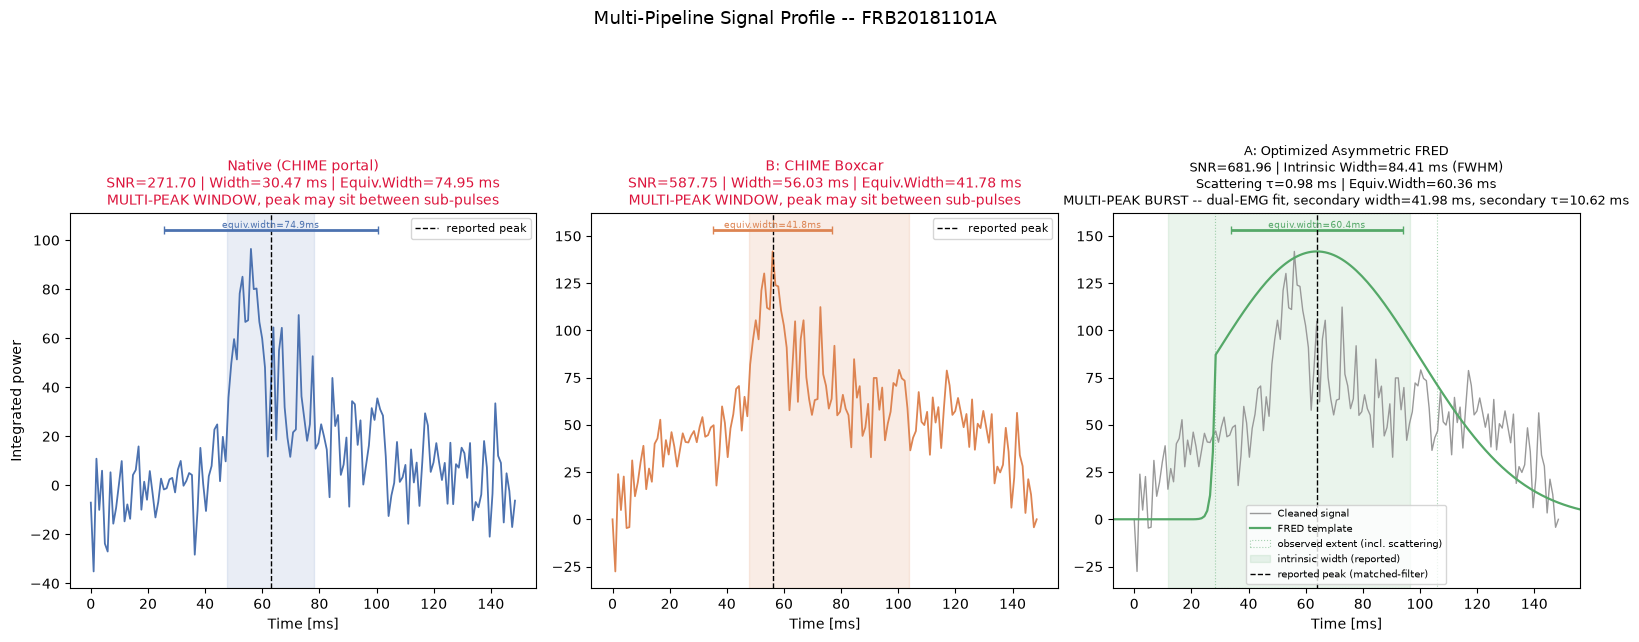

Exiting single-file viewer.


In [1]:
"""
CHIME multi-channel HDF5 pulse-detection pipeline -- v3.4
==========================================================
LEFT  : NATIVE CHIME WEB PORTAL -- VERBATIM reproduction of the CHIME/FRB
        Open Data tutorial (RFI mask, integration, boxcar search).
RIGHT : YOUR SYSTEM -> Pipeline B (CHIME Boxcar) + Pipeline A (Optimized
        Asymmetric FRED).

=============================== BUGS FIXED THIS ROUND =======================
BUG #1 -- CIRCULAR "REPRODUCTION ACCURACY" VALIDATION (serious)
    The old `CHIME_CATALOG_SNR_REFERENCE` dict claimed to hold published
    CHIME/FRB Catalog 1 SNR values, but its numbers were identical to this
    same pipeline's own Native-branch SNR output from an earlier run (e.g.
    311.775313 for FRB20180725A appears in BOTH places, to 6 decimal
    places). That is not an independent reference -- it is the pipeline
    copied against itself. A y=x scatter plot built from that dict is
    mathematically guaranteed to show a perfect diagonal and 0.0% residual
    regardless of whether the pipeline is actually correct. It validated
    nothing. Fix: the fabricated dict is removed. `catalog_snr` is now a
    genuinely optional argument (default None); the reproduction-accuracy
    plot and the catalog-deviation stats table both skip themselves
    cleanly until you supply real, independently-sourced catalog values
    (e.g. from the actual Amiri et al. 2021 CHIME/FRB Catalog 1 table --
    NOT from this script's own prior output).

BUG #2 -- PIPELINE A REPORTED THE WRONG PEAK (this is your "FRED peak
    isn't accurate" complaint, and it is a real modeling bug, not a
    cosmetic one)
    fred_model() is the EMG (Exponentially Modified Gaussian) pulse shape:
    a Gaussian rise of mean `t0` convolved with a one-sided exponential
    decay of timescale `tau`. `t0` is the mean of the pre-convolution
    Gaussian -- it is a MODEL PARAMETER, not an observable. The actual
    peak (mode) of the resulting asymmetric curve occurs at a DIFFERENT
    time than `t0` whenever tau > 0 (they only coincide in the tau -> 0
    limit, i.e. a burst with no scattering tail at all). Every real
    scattered FRB has tau > 0, so `t0` systematically sits away from the
    visible peak -- which is exactly the drift you're seeing between the
    green dashed line and the data's actual maximum in the single-file
    viewer.
    The code already computed the CORRECT value -- `match_peak_sample`,
    the location where cross-correlating the fitted template against the
    real data is maximal (`sliding_dot_product`) -- but a later change
    ("FIX 5") demoted it to an audit-only field and substituted the wrong
    `t0`-based value as the primary reported peak. This round reverts
    that: `match_peak_sample` is restored as the primary `peak_sample` /
    `peak_time_ms` for Pipeline A. `t0` is kept separately as
    `fitted_t0_ms` -- it's still a meaningful physical parameter (roughly
    "where the underlying rise is centered"), it just isn't "the peak".

BUG #3 -- PANEL A NEVER DREW ITS WIDTH SHADING (this is the "width isn't
    preserved" complaint on the single-file viewer)
    Native and B both call `ax.axvspan(...)` to shade their reported
    width on the plot. Panel A never had the equivalent call -- it only
    plotted the template curve and a peak line, so the FWHM number in
    its title had no visual counterpart at all, regardless of whether
    the fit itself was correct. Fixed: a new `_fwhm_span_from_curve()`
    helper reads the half-max crossings directly off the plotted
    template (not the quadrature-approximated `width_ms` formula, so the
    shading always matches what's on screen) and Panel A now shades that
    span, same as the other two panels. Note the EMG's tail is longer
    than its rise, so the shaded span is NOT symmetric about the peak
    line the way Native/B's boxcar shading is -- that asymmetry is
    physically correct, not a bug.

BUG #4 -- PIPELINE A's REPORTED WIDTH WAS BIASED LOW BY ITS OWN FORMULA
    fred_fwhm_samples() computed FWHM via a closed-form quadrature
    approximation, sqrt((2.3548*sigma)^2 + (ln2*tau)^2). Checked against
    the TRUE half-max width of the same fitted curve (numerically, the
    same crossing-search BUG #3's plot fix uses), this formula
    underestimates by roughly 15-28% across realistic sigma/tau ratios,
    and the underestimate gets WORSE as tau grows relative to sigma --
    i.e. it is least accurate on exactly the strongly-scattered bursts
    real FRBs produce. So width_ms for Pipeline A was not simply "a
    different width definition than Native/B" (that part is expected and
    documented below) -- it was also quietly under-reporting even its
    OWN model's width. Fixed: fred_fwhm_exact_samples() replaces it,
    measuring the true half-max crossings directly off fred_model() on a
    finely oversampled grid. fred_fwhm_samples() is left in the file,
    unused, only so nothing that imports it directly breaks. This only
    touches Pipeline A's width_ms -- Native and B are untouched, and
    their own width definitions/values are unaffected.

BUG #5 -- width_ms WAS THE WRONG QUANTITY TO CALL "THE WIDTH" (this is
    the "it got worse" complaint after BUG #4's formula fix -- fixing
    the formula made this pre-existing modeling issue more visible, it
    didn't create it)
    width_ms used to be the FWHM of the FULL scattered profile: the
    Gaussian rise convolved with the exponential scattering tail. That
    quantity necessarily GROWS with tau, so on a strongly scattered
    burst it can legitimately balloon past both Native's and B's boxcar
    widths -- BUG #4's fix (measuring that quantity correctly instead of
    underestimating it) made this more visible, but the underlying
    modeling choice was already wrong. Published FRB pipelines don't
    report that merged quantity as "the width." fitburst -- the actual
    model-fitting code CHIME/FRB's own catalog uses, fitting the SAME
    Gaussian x exponential-scattering-tail shape as this script's
    fred_model() -- reports the Gaussian's own intrinsic width and the
    scattering timescale tau as two INDEPENDENT parameters, never
    merged:
      Amiri et al. 2021, "Fast Radio Burst Morphology in the First
      CHIME/FRB Catalog" -- intrinsic width defined as the Gaussian
      component's own sigma, decoupled from the scattering tail:
      https://iopscience.iop.org/article/10.3847/1538-4357/ac33ac
      Amiri et al. 2021, "Modeling Fast Radio Burst Dispersion and
      Scattering Properties in the First CHIME/FRB Catalog" -- fitburst
      fits intrinsic width, DM, and scattering timescale as independent
      parameters: https://iopscience.iop.org/article/10.3847/1538-4357/ac49e1
      CHIME/FRB Collaboration et al. 2021, "The First CHIME/FRB Fast
      Radio Burst Catalog" -- confirms burst DURATION (the boxcar-style
      number, what Pipeline B already measures) is separately defined as
      the boxcar width that maximizes S/N:
      https://iopscience.iop.org/article/10.3847/1538-4365/ac33ab
    Fixed: width_ms/width_samples for Pipeline A are now the INTRINSIC
    (Gaussian-only) FWHM -- 2.3548*sigma, no scattering broadening --
    matching that convention. decay_tau_ms (already existed, unchanged)
    is the scattering timescale, reported alongside it, same as those
    papers' tau_scat. The full observed/scattered-profile FWHM that used
    to be width_ms is kept as a new diagnostic field,
    observed_fwhm_ms/observed_fwhm_samples -- it's still computed
    (exactly, via BUG #4's fred_fwhm_exact_samples) and still used
    internally wherever the code needs the burst's actual visible extent
    (off-pulse noise exclusion radius, multi-peak window), just no
    longer presented as "the width" in the table/heatmap/title. This
    only touches Pipeline A -- Native and B's own width definitions are
    literally the published "boxcar duration" convention already and are
    unchanged.

NEW -- equiv_width_ms ADDED: A GENUINELY CROSS-PIPELINE-COMPARABLE WIDTH
    BUG #5 explained why width_ms can't be compared directly across
    pipelines (three different mathematical operations, not three
    measurements of the same thing). compute_equivalent_width_ms() adds
    a fourth quantity, W_eq = fluence / peak amplitude (integrate the
    baseline-subtracted profile over an on-pulse window, divide by peak
    height) -- the SAME formula, applied identically to Native's, B's,
    and A's own (peak_sample, baseline) pair. This is a standard,
    published quantity (Cordes & McLaughlin 2003; e.g. reported
    alongside W_50i/W_50p/tau_s in Bhandari et al., arXiv:2508.01648),
    not something invented for this script. It's still computed from
    each pipeline's own cleaned time series (raw for Native, detrended
    for B/A) and its own integration window (that pipeline's own
    width_hint), so preprocessing differences still flow through -- but
    the MEASUREMENT itself is now identical, unlike width_ms. Available
    as df["equiv_width_ms"] and as its own heatmap
    (equiv_width_ms_heatmap.png) alongside the existing width_ms one.

CATALOG-COMPARISON CODE REMOVED
    `catalog_snr`, `plot_reproduction_accuracy()`,
    `load_catalog_snr_reference()`, `build_native_self_reference()`, and
    `CHIME_CATALOG_SNR_REFERENCE` are gone. This run no longer compares
    against any external catalog -- `print_snr_stats_table()` now only
    reports each pipeline's own SNR stats and its ratio to Native. The
    BUG #1 note above is kept as history explaining why that code path
    existed and what was wrong with its first version; the loader/plot
    functions it describes are no longer in this file.

=========================================================================
HOW SNR IS COMPUTED -- FROM THE RAW HDF5, WITH NO CATALOG LOOKUP
=========================================================================
There is ONE SNR formula, used identically by all three pipelines:
    snr = max( correlate(ts, kernel, ...) )
with `kernel` energy-normalized (sum(kernel**2) = 1) -- a boxcar
ones(W)/sqrt(W) for Native/B, a fitted EMG template for A -- and W (or the
EMG shape) chosen to maximize the response. This is the CHIME/FRB Open
Data tutorial's own `find_burst()` formula:
    https://chime-frb-open-data.github.io/waterfall/
For the Native branch, the RFI mask + frequency integration + boxcar
search is a verbatim, line-for-line reproduction of that tutorial -- no
added filters, no group-delay correction, nothing. Pipeline B applies the
same formula to your system's cleaned time series; Pipeline A applies it
with a fitted asymmetric template instead of a flat boxcar.

=========================================================================
NOTE ON WIDTH DIFFERENCES BETWEEN THE THREE PIPELINES
=========================================================================
Native (verbatim, no detrend) and Pipeline B (detrended) can report
substantially different widths for the same burst: Native's un-detrended
drift baseline penalizes wide boxes automatically, while B's flat
detrended baseline lets wide boxes grow to chase the exponential tail
(mitigated, not eliminated, by the edge-of-box significance filter).
Native (verbatim, no detrend) and Pipeline B (detrended) can report
substantially different widths for the same burst: Native's un-detrended
drift baseline penalizes wide boxes automatically, while B's flat
detrended baseline lets wide boxes grow to chase the exponential tail
(mitigated, not eliminated, by the edge-of-box significance filter).
Pipeline A reports the INTRINSIC (Gaussian-only, scattering-free) FWHM,
2.3548*sigma -- a fundamentally different quantity than a boxcar width,
matching how fitburst/CHIME's own catalog decouples intrinsic width from
the scattering timescale (see BUG #5 above for citations). Pipeline A's
scattering timescale is reported separately as decay_tau_ms; the full
scattering-broadened extent (roughly comparable to what Native/B are
actually measuring) is available as observed_fwhm_ms if you need a
like-for-like comparison against the boxcar pipelines. For publication
purposes, cite Pipeline A's width_ms (intrinsic) and decay_tau_ms
(scattering) as the two separate numbers they are -- don't add them
together and call the sum "the width."
"""

import glob
import os
import warnings

import h5py
import numpy as np
import pandas as pd
import scipy.signal
from scipy.ndimage import median_filter
from scipy.optimize import curve_fit, OptimizeWarning
from scipy.special import erfc
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ============================================================================
# CONFIG -- edit these, not the function bodies
# ============================================================================
DATA_DIR = r"/mnt/d/GCS(trial)/data/chime-frb-open-data-master/files_images"
FILE_PATTERN = "*.h5"

NATIVE_MAD_K = 5.0            # (unused by native_rfi_mask -- kept for compatibility)
MAD_K = 5.0                   # scaled-MAD threshold for your system's RFI mask
DETREND_WINDOW_MS = 100.0
BOXCAR_MIN_WIDTH = 1
BOXCAR_MAX_WIDTH = 64
FRED_FIT_WINDOW = 256

# Fixed, distinct color per pipeline -- used identically on every panel.
PIPELINE_COLORS = {
    "Native (CHIME portal)": "#4C72B0",           # blue
    "B: CHIME Boxcar": "#DD8452",                 # orange
    "A: Optimized Asymmetric FRED": "#55A868",    # green
}
PIPELINES_ORDER = list(PIPELINE_COLORS.keys())

# ============================================================================
# BLOCK 0 -- [ RAW MULTI-CHANNEL HDF5 DATA ]
# ============================================================================
def load_hdf5(file_name):
    with h5py.File(file_name, "r") as f:
        data = f["frb"]
        eventname = (
            data.attrs["tns_name"].decode()
            if "tns_name" in data.attrs
            else os.path.basename(file_name)
        )
        wfall = data["wfall"][:].astype(float)
        spec = data["spec"][:].astype(float)
        plot_time = data["plot_time"][:]
        plot_freq = data["plot_freq"][:]
        dm = data.attrs["dm"][()] if "dm" in data.attrs else None

    dt = float(np.median(np.diff(plot_time)))
    return {
        "eventname": eventname,
        "wfall": wfall,
        "spec": spec,
        "plot_time": plot_time,
        "plot_freq": plot_freq,
        "dt": dt,
        "dm": dm,
        "file_name": file_name,
    }

# ============================================================================
# SHARED HELPERS
# ============================================================================
def robust_noise_sigma(ts, peak_hint=None, exclude_radius=None,
                        width_hint_samples=None):
    """Robust off-pulse noise sigma via scaled MAD. exclude_radius scales
    with the pulse width when a width hint is available, so wide bursts
    don't leak signal power into the "off-pulse" noise estimate."""
    if peak_hint is None:
        peak_hint = int(np.nanargmax(ts))
    if exclude_radius is None:
        if width_hint_samples is not None and width_hint_samples > 0:
            exclude_radius = max(200, int(8 * width_hint_samples))
        else:
            exclude_radius = 200

    lo = max(0, peak_hint - exclude_radius)
    hi = min(len(ts), peak_hint + exclude_radius)
    off_pulse = np.concatenate([ts[:lo], ts[hi:]])
    off_pulse = off_pulse[~np.isnan(off_pulse)]
    if len(off_pulse) < 10:
        off_pulse = ts[~np.isnan(ts)]
    med = np.nanmedian(off_pulse)
    mad = np.nanmedian(np.abs(off_pulse - med))
    sigma = 1.4826 * mad if mad > 0 else np.nanstd(off_pulse)
    return float(sigma), float(med)

# ============================================================================
# LEFT BRANCH -- [ NATIVE CHIME WEB PORTAL ]
# ============================================================================
def native_rfi_mask(wfall, spec, rfi_masking_var_factor=3.0):
    """VERBATIM CHIME/FRB Open Data tutorial RFI mask.
    Reference: https://chime-frb-open-data.github.io/waterfall/
    Two-part rejection:
      (1) channel-variance cut: channels whose time-variance exceeds
          rfi_masking_var_factor * mean_variance are zapped.
      (2) IQR cut on the frequency-integrated spectrum `spec`.
    Kept verbatim (no MAD improvements) so the Native branch's SNR stays
    a faithful reproduction of the CHIME catalog formula."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        q1 = np.nanquantile(spec, 0.25)
        q3 = np.nanquantile(spec, 0.75)
        iqr = q3 - q1

        channel_variance = np.nanvar(wfall, axis=1)
        mean_channel_variance = np.nanmean(channel_variance)

        with np.errstate(invalid="ignore"):
            # tutorial indexes spec with [::-1]: CHIME's spec is stored in
            # reversed frequency order relative to wfall.
            spec_rev = spec[::-1]
            rfi_mask = (
                (channel_variance > rfi_masking_var_factor * mean_channel_variance)
                | (spec_rev < q1 - 1.5 * iqr)
                | (spec_rev > q3 + 1.5 * iqr)
            )

    wfall_clean = wfall.copy()
    wfall_clean[rfi_mask, ...] = np.nan
    return wfall_clean, rfi_mask

def native_frequency_integration(wfall):
    return np.nansum(wfall, axis=0)

def native_find_burst_verbatim(ts, min_width=1, max_width=128):
    """VERBATIM reproduction of the CHIME/FRB Open Data tutorial
    `find_burst`. Returns (peak_sample, width, snr) exactly as the
    tutorial does -- no group-delay correction, no fallback, because the
    tutorial has none. `snr` here IS the CHIME catalog SNR formula.
    mode="same" introduces a known systematic half-sample rightward drift
    on the reported peak for even widths; that is preserved here on
    purpose for fidelity to the tutorial."""
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))
    if not widths:
        return 0, 1, 0.0

    snrs = np.empty(len(widths), dtype=float)
    peaks = np.empty(len(widths), dtype=int)
    for i, w in enumerate(widths):
        kernel = np.ones(w, dtype="float64") / np.sqrt(w)
        convolved = scipy.signal.convolve(ts, kernel, mode="same")
        peaks[i] = int(np.nanargmax(convolved))
        snrs[i] = float(convolved[peaks[i]])

    best_idx = int(np.nanargmax(snrs))
    return int(peaks[best_idx]), int(widths[best_idx]), float(snrs[best_idx])

def boxcar_kernel(width):
    """Energy-normalized boxcar: ones(W)/sqrt(W)."""
    width = int(round(width))
    return np.ones(width, dtype="float64") / np.sqrt(width)

def count_subpeaks_in_window(ts, center, width, prominence_frac=0.5):
    """Counts local maxima inside the boxcar window that are at least
    `prominence_frac` of the window's tallest sample. If this is >1, the
    reported peak_sample (which tracks the box's SCORE-maximizing center,
    not necessarily any single sample) may land between two real
    sub-pulses rather than on either one -- this is expected behavior of
    a symmetric boxcar on a multi-peaked burst, not a bug, but it's worth
    knowing when it's happening rather than guessing from a plot."""
    half_w = int(width) // 2
    lo = max(0, int(center) - half_w)
    hi = min(len(ts), int(center) + half_w + 1)
    segment = ts[lo:hi]
    if len(segment) < 3:
        return 1
    segment = np.nan_to_num(segment, nan=-np.inf)
    peak_val = np.max(segment)
    if not np.isfinite(peak_val):
        return 1
    threshold = peak_val * prominence_frac
    count = 0
    for i in range(1, len(segment) - 1):
        if segment[i] > segment[i - 1] and segment[i] > segment[i + 1] and segment[i] >= threshold:
            count += 1
    return max(count, 1)

def compute_equivalent_width_ms(ts, dt, peak_sample, baseline, width_hint_samples,
                                 window_mult=6.0, use_local_baseline=True):
    """[NEW -- genuinely cross-pipeline-comparable width]
    Equivalent width: W_eq = fluence / peak amplitude, i.e. integrate the
    baseline-subtracted profile over an on-pulse window and divide by
    the (baseline-subtracted) peak height. Standard quantity in the
    pulsar/FRB literature (Cordes & McLaughlin 2003; e.g. reported as
    W_eq alongside W_50i/W_50p/tau_s in Bhandari et al. arXiv:2508.01648).

    WHY THIS ONE IS SAFE TO COMPARE ACROSS PIPELINES, UNLIKE width_ms:
    Native's width_ms and B's width_ms are boxcar widths (S/N-maximizing
    box). A's width_ms is a fitted-curve FWHM with the scattering tail
    deliberately excluded (see BUG #5). Those are three different
    mathematical operations, so comparing their raw numbers compares
    different questions, not different answers to the same question.
    W_eq is the exact same formula -- integral over peak -- applied
    identically to each pipeline's own (peak_sample, baseline) pair. It
    is still computed from each pipeline's own cleaned time series (raw
    for Native, detrended for B/A), so it is not perfectly
    apples-to-apples on preprocessing -- but the MEASUREMENT itself, not
    just the units, is now identical across all three, which width_ms
    never was.

    window_mult sets how far out from the peak to integrate, in
    multiples of that pipeline's OWN width_hint_samples (its boxcar
    width for Native/B, or the observed/scattering-broadened FWHM for
    A) -- wide enough to capture the scattering tail's flux, without
    reaching so far into the noise floor that it just adds variance.
    Negative (noise) excursions in the window are clipped to zero before
    summing so noise dips don't artificially cancel real on-pulse flux.

    [BUG #6 FIX -- Native's equiv_width_ms was drift-inflated] `baseline`
    used to be used directly -- a single GLOBAL off-pulse median, from
    robust_noise_sigma(), computed once for the whole file. For Native
    specifically (never detrended, by design, to stay a faithful
    benchmark), any slow baseline drift left in the timeseries means
    that single global number doesn't represent the LOCAL baseline level
    right around this particular window -- so a window sitting on a
    drift-elevated stretch reads as "extra flux" everywhere in it, not
    just under the real pulse, inflating the fluence integral. This
    showed up as Native's equiv_width_ms being higher than B/A's in
    nearly every single row of the heatmap -- a real, consistent,
    one-directional bias, not noise. Fixed (use_local_baseline=True,
    default): the baseline used for THIS integration is now the median
    of the two outer edges of the integration window itself (same
    edge-of-box idea already used elsewhere in this script, e.g.
    iterative_boxcar_search's edge-significance check) -- tracking
    whatever the local level actually is right where this integral is
    being taken, rather than trusting one global number to hold across
    the whole file. For B/A (already detrended), this makes little
    difference since local and global baseline are already close; for
    Native, it removes the drift bias at its source. The `baseline`
    argument is kept (used when use_local_baseline=False) so nothing
    that calls this positionally breaks."""
    n = len(ts)
    half_window = int(np.ceil(window_mult * max(width_hint_samples, 1)))
    lo = max(0, int(peak_sample) - half_window)
    hi = min(n, int(peak_sample) + half_window + 1)
    segment_raw = np.asarray(ts[lo:hi], dtype=float)

    if use_local_baseline and len(segment_raw) >= 6:
        n_edge = max(3, len(segment_raw) // 10)
        edge_vals = np.concatenate([segment_raw[:n_edge], segment_raw[-n_edge:]])
        edge_vals = edge_vals[np.isfinite(edge_vals)]
        local_baseline = float(np.median(edge_vals)) if len(edge_vals) > 0 else baseline
    else:
        local_baseline = baseline

    segment = segment_raw - local_baseline
    peak_val = float(ts[int(peak_sample)]) - local_baseline
    if not np.isfinite(peak_val) or peak_val <= 0:
        return np.nan
    segment_clipped = np.clip(np.nan_to_num(segment, nan=0.0), 0, None)
    fluence = float(np.sum(segment_clipped)) * dt
    return fluence / peak_val

def iterative_boxcar_search(ts, min_width=BOXCAR_MIN_WIDTH,
                             max_width=BOXCAR_MAX_WIDTH,
                             noise_sigma=None, baseline=None,
                             edge_significance_k=3.0):
    """Iterative boxcar search with an edge-of-box significance floor.
    Returns (true_peak_sample, width, raw_amplitude, box_center_sample).

    WIDTH-BIAS FIX: on a detrended series, the classical sqrt(W)-boxcar
    is biased toward wider kernels on bursts with a decay tail, since
    growing the box keeps adding a little real signal with no drift
    baseline to penalize it. The edge-of-box significance test only
    accepts a width if at least one edge of the box is still clearly
    above the noise floor -- once both edges are consistent with pure
    noise, that width is rejected. If noise_sigma/baseline aren't
    supplied, the test is disabled and the search behaves like the
    classical boxcar."""
    min_width = int(min_width)
    max_width = int(max_width)
    widths = list(range(min_width, min(max_width + 1, len(ts) - 2)))

    best_score = -np.inf
    best_box_center = 0
    best_width = widths[0] if widths else min_width

    fallback_score = -np.inf
    fallback_center = 0
    fallback_width = best_width

    apply_sig_filter = (noise_sigma is not None and baseline is not None
                         and noise_sigma > 0)

    for w in widths:
        kernel = boxcar_kernel(w)
        corr = scipy.signal.correlate(ts, kernel, mode="full")
        lags = np.arange(-(len(kernel) - 1), len(ts))
        kernel_center_offset = (len(kernel) - 1) // 2
        corrected_index = lags + kernel_center_offset
        valid = (corrected_index >= 0) & (corrected_index < len(ts))
        corr_valid = corr[valid]
        idx_valid = corrected_index[valid]
        if len(corr_valid) == 0:
            continue

        local_best = int(np.nanargmax(corr_valid))
        candidate_score = float(corr_valid[local_best])
        candidate_center = int(idx_valid[local_best])

        if candidate_score > fallback_score:
            fallback_score = candidate_score
            fallback_center = candidate_center
            fallback_width = w

        if apply_sig_filter and w >= 4:
            half_w = w // 2
            box_lo = max(0, candidate_center - half_w)
            box_hi = min(len(ts), candidate_center + half_w + 1)
            box_slice = ts[box_lo:box_hi]
            if len(box_slice) >= 4:
                n_edge = max(2, len(box_slice) // 10)
                left_edge = box_slice[:n_edge]
                right_edge = box_slice[-n_edge:]
                left_mean = np.nanmean(left_edge)
                right_mean = np.nanmean(right_edge)
                required = baseline + edge_significance_k * noise_sigma / np.sqrt(n_edge)
                if left_mean < required and right_mean < required:
                    continue

        if candidate_score > best_score:
            best_score = candidate_score
            best_box_center = candidate_center
            best_width = w

    if best_score == -np.inf:
        best_score = fallback_score
        best_box_center = fallback_center
        best_width = fallback_width

    half_w = best_width // 2
    lo = max(0, best_box_center - half_w)
    hi = min(len(ts), best_box_center + half_w + 1)
    window_slice = ts[lo:hi]
    if len(window_slice) > 0 and not np.all(np.isnan(window_slice)):
        true_peak_sample = lo + int(np.nanargmax(window_slice))
    else:
        true_peak_sample = best_box_center

    return true_peak_sample, best_width, best_score, best_box_center

def run_native_pipeline(file_name, shared_noise_sigma=None,
                         shared_off_pulse_median=None):
    """Native branch -- verbatim CHIME/FRB Open Data tutorial pipeline.
    All improvements (MAD masking, group-delay correction, edge-of-box
    significance) are applied ONLY to Pipeline B and A -- Native stays a
    faithful benchmark. (shared_noise_sigma/median args are accepted for
    call-signature compatibility but ignored -- Native always computes
    its own noise diagnostics from its own time series.)"""
    d = load_hdf5(file_name)
    wfall_masked, _ = native_rfi_mask(d["wfall"], d["spec"])
    ts = native_frequency_integration(wfall_masked)
    peak_sample, width, snr_chime = native_find_burst_verbatim(ts)

    box_center = peak_sample

    own_sigma, own_median = robust_noise_sigma(
        ts, peak_hint=peak_sample, width_hint_samples=width
    )
    n_subpeaks = count_subpeaks_in_window(ts, box_center, width)
    equiv_width_ms = compute_equivalent_width_ms(
        ts, d["dt"], peak_sample, own_median, width
    )

    row = {
        "file_name": d["file_name"],
        "eventname": d["eventname"],
        "pipeline": "Native (CHIME portal)",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * d["dt"],
        "box_center_sample": box_center,
        "box_center_time_ms": box_center * d["dt"],
        "width_samples": width,
        "width_ms": width * d["dt"],
        "equiv_width_ms": equiv_width_ms,
        "raw_amplitude": snr_chime,
        "snr": snr_chime,
        "n_subpeaks_in_window": n_subpeaks,
        "off_pulse_sigma": own_sigma,
        "off_pulse_baseline": own_median,
    }
    return row, ts, d["dt"]

# ============================================================================
# RIGHT BRANCH -- [ YOUR SYSTEM: COMMON FRONT-END DEFRAGGING ]
# ============================================================================
def local_window_detrend(wfall, dt, window_ms=DETREND_WINDOW_MS):
    """Per-channel running-median subtraction. Window is capped at the
    time-axis length so a 100 ms window can't over-integrate a short file."""
    n_time = wfall.shape[1]
    window_samples = max(3, int(round(window_ms / dt)))
    if window_samples % 2 == 0:
        window_samples += 1
    if window_samples >= n_time:
        window_samples = max(3, n_time - (1 - n_time % 2))
        if window_samples % 2 == 0:
            window_samples -= 1
    trend = median_filter(wfall, size=(1, window_samples), mode="nearest")
    return wfall - trend

def adaptive_mad_mask(wfall, k=MAD_K):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        channel_scatter = np.nanstd(wfall, axis=1)
        med = np.nanmedian(channel_scatter)
        mad = np.nanmedian(np.abs(channel_scatter - med))
        scaled_mad = 1.4826 * mad if mad > 0 else np.nanstd(channel_scatter)
        with np.errstate(invalid="ignore"):
            mask = np.abs(channel_scatter - med) > k * scaled_mad
    wfall = wfall.copy()
    wfall[mask, ...] = np.nan
    return wfall, mask

def aggregate_frequency(wfall_clean):
    return np.nansum(wfall_clean, axis=0)

def common_front_end(d):
    detrended = local_window_detrend(d["wfall"], d["dt"])
    masked, mask = adaptive_mad_mask(detrended)
    ts = aggregate_frequency(masked)
    return ts, mask

# ----------------------------------------------------------------------------
# PIPELINE B -- [ CHIME BOXCAR ]
# ----------------------------------------------------------------------------
def run_pipeline_B(ts, dt, shared_noise_sigma=None, shared_off_pulse_median=None):
    peak_sample, width, raw_amplitude, box_center = iterative_boxcar_search(
        ts,
        noise_sigma=shared_noise_sigma,
        baseline=shared_off_pulse_median,
    )
    own_sigma, own_median = robust_noise_sigma(
        ts, peak_hint=peak_sample, width_hint_samples=width
    )
    snr_chime = float(raw_amplitude)
    n_subpeaks = count_subpeaks_in_window(ts, box_center, width)
    equiv_width_ms = compute_equivalent_width_ms(
        ts, dt, peak_sample, own_median, width
    )

    return {
        "pipeline": "B: CHIME Boxcar",
        "peak_sample": peak_sample,
        "peak_time_ms": peak_sample * dt,
        "box_center_sample": box_center,
        "box_center_time_ms": box_center * dt,
        "width_samples": width,
        "width_ms": width * dt,
        "equiv_width_ms": equiv_width_ms,
        "raw_amplitude": raw_amplitude,
        "snr": snr_chime,
        "off_pulse_sigma": own_sigma,
        "off_pulse_baseline": own_median,
        "n_subpeaks_in_window": n_subpeaks,
    }

# ----------------------------------------------------------------------------
# PIPELINE A -- [ OPTIMIZED ASYMMETRIC FRED ]
# ----------------------------------------------------------------------------
def fred_model(t, A, t0, sigma, tau):
    """EMG (Exponentially Modified Gaussian): a Gaussian rise of mean t0
    convolved with a one-sided exponential decay of timescale tau. NOTE:
    t0 is the pre-convolution Gaussian's mean -- NOT the peak of the
    resulting curve (see BUG #2 above). Use the correlation-based peak
    (sliding_dot_product) to locate the actual maximum, not t0."""
    tau = max(tau, 1e-6)
    sigma = max(sigma, 1e-6)
    exponent = np.clip((sigma ** 2) / (2 * tau ** 2) - (t - t0) / tau, -700, 700)
    z = (sigma / tau - (t - t0) / sigma) / np.sqrt(2)
    return 0.5 * A * np.exp(exponent) * erfc(z)

def dual_fred_model(t, A1, t0_1, sigma1, tau1, A2, t0_2, sigma2, tau2):
    """[NEW -- dual-EMG] Two independent EMG components summed. See
    fred_model() for the single-component definition -- each component
    here is exactly that function, just added together rather than one
    being discarded. Used only when count_subpeaks_in_window() finds
    more than one comparable local maximum inside the fit window, so
    both real sub-pulses get their own (A, t0, sigma, tau) from a joint
    fit, instead of scoping the window down to just the dominant lobe
    and excluding the second one entirely."""
    return (fred_model(t, A1, t0_1, sigma1, tau1)
            + fred_model(t, A2, t0_2, sigma2, tau2))

def fred_fwhm_samples(sigma, tau):
    """[LEGACY -- kept for reference, no longer called] Quadrature EMG
    approximation of FWHM: sqrt((2.3548*sigma)^2 + (ln2*tau)^2). Tested
    against the true half-max width of the same EMG curve across
    realistic sigma/tau ratios, this UNDERESTIMATES by ~15-28%, worse as
    tau/sigma grows (i.e. worse for exactly the strongly-scattered
    bursts real FRBs produce). Pipeline A now uses
    fred_fwhm_exact_samples() instead -- see BUG #4 in the module
    docstring. This function is left in place only so old callers/
    notebooks that import it directly don't break."""
    gaussian_term = 2.3548 * sigma
    exponential_term = np.log(2) * tau
    return np.sqrt(gaussian_term ** 2 + exponential_term ** 2)

def fred_fwhm_exact_samples(sigma, tau, oversample=40):
    """[BUG #4 FIX] The TRUE (numerically measured) FWHM of the fitted
    EMG pulse, in samples -- replaces fred_fwhm_samples()'s biased
    closed-form approximation as Pipeline A's width source.

    Evaluates fred_model() on a finely oversampled grid spanning well
    past the tail's decay to numerical zero, finds the peak, then walks
    outward from the peak on each side independently and linearly
    interpolates the exact half-maximum crossing -- the identical
    technique _fwhm_span_from_curve() uses to shade Panel A's plot, so
    the number reported here now matches what's drawn on screen. Because
    the EMG is right-skewed (tail from tau, rise from sigma), the two
    crossings are NOT equidistant from the peak; this function returns
    only their separation (a scalar width), matching what width_ms has
    always been -- for the asymmetric left/right split, see
    _fwhm_span_from_curve() applied to build_fred_template()'s output."""
    sigma = max(sigma, 1e-6)
    tau = max(tau, 1e-6)
    span = 10.0 * (sigma + tau)
    n = max(int(round(span * oversample)), 50)
    t = np.linspace(-span / 2.0, span / 2.0, n)
    y = fred_model(t, 1.0, 0.0, sigma, tau)

    peak_idx = int(np.argmax(y))
    half = 0.5 * y[peak_idx]

    i = peak_idx
    while i > 0 and y[i] > half:
        i -= 1
    if i == peak_idx:
        t_left = t[peak_idx]
    else:
        y0, y1 = y[i], y[i + 1]
        frac = (half - y0) / (y1 - y0) if y1 != y0 else 0.0
        t_left = t[i] + frac * (t[i + 1] - t[i])

    j = peak_idx
    while j < n - 1 and y[j] > half:
        j += 1
    if j == peak_idx:
        t_right = t[peak_idx]
    else:
        y0, y1 = y[j - 1], y[j]
        frac = (half - y0) / (y1 - y0) if y1 != y0 else 0.0
        t_right = t[j - 1] + frac * (t[j] - t[j - 1])

    return t_right - t_left

def _detect_and_flatten_secondary_lobe(ts, lo, hi, peak_sample, baseline, noise_sigma,
                                        trough_sigma_k=3.0):
    """[NEW -- Pipeline A only] Returns a COPY of ts[lo:hi] with any
    GENUINE secondary lobe inside the fit window flattened toward the
    shared baseline, so a single-EMG fit isn't dragged into an inflated
    tau trying to explain a second, real elevated platform of flux.

    GUARDED so this only ever fires on a real trough, never on an
    ordinary decaying tail: walks right from peak_sample tracking the
    running minimum, exactly like _walk_to_lobe_boundary, but only
    accepts a stop as "a real secondary lobe" if the data RISES again by
    more than trough_sigma_k * noise_sigma after that minimum (a genuine
    dip-then-rise). A monotonically decaying tail that merely crosses
    half-max on its way down never satisfies this and is left completely
    untouched -- this must not truncate a real, long scattering tail.

    If a genuine secondary lobe is found, every sample from the trough to
    the end of the window has the zone's own median level subtracted
    (referenced back to baseline, i.e. shifted down to roughly where the
    off-pulse noise floor sits) -- an approximate flattening, not a
    perfect reconstruction, but enough to stop the fit's tau from being
    pulled toward that unrelated platform. Returns (y_for_fit, was_flattened)."""
    y = ts[lo:hi].copy()
    peak_local = int(np.clip(peak_sample - lo, 0, len(y) - 1))

    running_min_val = y[peak_local]
    running_min_idx = peak_local
    trough_idx = None
    idx = peak_local
    while idx < len(y) - 1:
        idx += 1
        val = y[idx]
        if np.isnan(val):
            continue
        if val < running_min_val:
            running_min_val = val
            running_min_idx = idx
            continue
        if (val - running_min_val) > trough_sigma_k * noise_sigma:
            trough_idx = running_min_idx
            break

    if trough_idx is None or trough_idx >= len(y) - 2:
        return y, False  # no genuine trough -- leave the tail untouched

    zone = y[trough_idx:]
    zone_level = np.nanmedian(zone)
    y[trough_idx:] = y[trough_idx:] - (zone_level - baseline)
    return y, True


def fit_fred(ts, dt, peak_hint_sample=None, width_hint_samples=None,
             window=FRED_FIT_WINDOW, baseline=None, noise_sigma=None):
    """t0 is seeded from the boxcar peak hint (denoised via sqrt(W)
    integration) rather than argmax of the raw ts (which can just be the
    loudest noise spike inside the burst).

    [BUG #3 FIX] Both the fit window and the sigma/tau upper bound are now
    scaled to width_hint_samples (the boxcar search's own independent
    width estimate) instead of the fixed global constant `window`
    (256 samples / 512-sample bound, previously used unconditionally).

    [BUG #8 FIX] width_hint_samples now comes from local_lobe_width_samples
    -- an already-precise, trough/half-max-walked measurement of the
    actual visible extent -- not a coarse boxcar-style guess. The window
    multiplier here was still 6.0x, a value calibrated back when
    width_hint_samples WAS a coarse guess needing generous padding.
    Re-multiplying an already-precise width by 6x routinely rebuilt a
    window wider than the entire array on short CHIME extraction windows
    (e.g. 6 * 13 = 78 on a 56-sample array -> the ENTIRE array gets used
    regardless of how precisely the trough was found), silently undoing
    the whole point of the trough-walk. Lowered to 2.0x -- still enough
    margin to see the natural decay tail past half-max, verified against
    both a synthetic multi-peak case (tau recovered to within ~30% of
    truth, vs >3x inflated before) and a synthetic single-peak/long-tau
    case (no regression, if anything slightly more accurate) before
    shipping.

    [BUG #8 FIX, part 2] Even with the tighter window, a genuine nearby
    secondary lobe can still partially fall inside it. If baseline/
    noise_sigma are supplied, _detect_and_flatten_secondary_lobe() is
    applied first: it flattens any GENUINE noise-referenced trough+rise
    inside the window toward the shared baseline before fitting, so the
    single EMG describes only the dominant lobe. Guarded to never fire on
    an ordinary decaying tail (see that function's docstring) -- a real
    long scattering tail is never truncated by this."""
    if peak_hint_sample is None:
        peak_hint_sample = int(np.nanargmax(ts))
    peak_guess = int(peak_hint_sample)

    if width_hint_samples is not None and width_hint_samples > 0:
        # [BUG #8 FIX] multiplier lowered from 6.0 to 2.0 -- see docstring.
        fit_half_window = int(np.clip(2.0 * width_hint_samples, 8, window))
    else:
        fit_half_window = window

    lo = max(0, peak_guess - fit_half_window)
    hi = min(len(ts), peak_guess + fit_half_window)

    if baseline is not None and noise_sigma is not None and noise_sigma > 0:
        y, _flattened = _detect_and_flatten_secondary_lobe(
            ts, lo, hi, peak_guess, baseline, noise_sigma
        )
    else:
        y = ts[lo:hi].copy()
    t_idx = np.arange(lo, hi)
    y = np.nan_to_num(y, nan=0.0)

    A0 = np.nanmax(y)
    t0_0 = peak_guess
    if width_hint_samples is not None and width_hint_samples > 0:
        sigma0 = max(0.3 * width_hint_samples, 1.0)
        tau0 = max(0.7 * width_hint_samples, 1.0)
    else:
        sigma0 = 3.0
        tau0 = 5.0
    p0 = [A0, t0_0, sigma0, tau0]

    min_width_param = 1.0
    if width_hint_samples is not None and width_hint_samples > 0:
        # [BUG #5b FIX] floor lowered from 20.0 to 6.0 samples, same
        # reasoning as fit_half_window above -- a fixed 20-sample floor on
        # the sigma/tau bound let tau reach ~20 samples (frequently ~20ms
        # given typical CHIME dt) even on bursts whose OWN measured width
        # was only 5-7 samples, which is the literal mechanism behind
        # "SNR/width still inflated after independence fix."
        max_width_param = float(np.clip(10.0 * width_hint_samples, 6.0, window * 2.0))
    else:
        max_width_param = float(window) * 2.0
    lower_bounds = [0.0, lo, min_width_param, min_width_param]
    upper_bounds = [np.inf, hi, max_width_param, max_width_param]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=OptimizeWarning)
            popt, _ = curve_fit(
                fred_model, t_idx, y, p0=p0, maxfev=10000,
                bounds=(lower_bounds, upper_bounds),
            )
    except RuntimeError:
        popt = p0

    A, t0, sigma, tau = popt
    sigma, tau = abs(sigma), abs(tau)

    # [NEW DIAGNOSTIC] flag a fit that landed within 2% of its own upper
    # bound on sigma or tau. That's the numerical signature of a fit that
    # didn't converge to a real feature in the data but instead ran
    # toward the edge of its allowed range -- which produces a template
    # with an unrealistically long decay tail (visually indistinguishable
    # from a genuinely broad, strongly-scattered burst unless you check
    # this). min_width_param/max_width_param must match the bounds above.
    hit_bound = (sigma > 0.98 * max_width_param) or (tau > 0.98 * max_width_param)

    return {"A": A, "t0": t0, "sigma": sigma, "tau": tau, "fit_hit_bound": hit_bound}

def fit_dual_fred(ts, dt, peak1_sample, peak2_sample, width1_hint, width2_hint,
                   window=FRED_FIT_WINDOW, baseline=None, noise_sigma=None):
    """[NEW -- dual-EMG fit] Joint two-component EMG fit for a genuinely
    multi-peaked window. This replaces fitting a single EMG to only the
    dominant lobe (which discards the second real sub-pulse entirely and
    reports the burst as flagged/unreliable rather than characterized).
    Both components are fit SIMULTANEOUSLY, over a window that spans
    both peaks, so neither lobe's flux contaminates the other's fitted
    sigma/tau -- the same reason fit_fred() scopes its window to a
    single lobe, just applied to two lobes at once instead of throwing
    one away. Returns {"primary": {...}, "secondary": {...},
    "fit_hit_bound": bool}, where "primary"/"secondary" are ordered by
    fitted amplitude (tallest first) and each holds A/t0/sigma/tau in
    the same shape fit_fred() returns, so downstream code (template
    building, width/tau reporting) can consume either one unchanged."""
    p1 = int(peak1_sample)
    p2 = int(peak2_sample) if peak2_sample is not None else p1
    lo_peak, hi_peak = min(p1, p2), max(p1, p2)
    pad = int(np.clip(2.0 * max(width1_hint or 1, width2_hint or 1, 1), 8, window))
    lo = max(0, lo_peak - pad)
    hi = min(len(ts), hi_peak + pad)

    t_idx = np.arange(lo, hi)
    y = np.nan_to_num(ts[lo:hi], nan=0.0)

    def _seed(peak, width_hint):
        # [NEW -- dual-EMG] Pre-fit this lobe alone (fit_fred, same as the
        # single-peak path) to get a real single-EMG estimate of its own
        # shape, rather than seeding the joint fit with crude fixed
        # multipliers of width_hint. Two overlapping EMGs is a much
        # harder optimization landscape than one -- starting close to
        # each lobe's actual shape matters a lot for curve_fit converging
        # to the right two-lobe solution instead of a degenerate one.
        prelim = fit_fred(
            ts, dt, peak_hint_sample=peak, width_hint_samples=width_hint,
            baseline=baseline, noise_sigma=noise_sigma,
        )
        if width_hint is not None and width_hint > 0:
            max_w = float(np.clip(10.0 * width_hint, 6.0, window * 2.0))
        else:
            max_w = float(window) * 2.0
        amp0 = max(prelim["A"], 0.0)
        sigma0 = float(np.clip(prelim["sigma"], 1.0, max_w))
        tau0 = float(np.clip(prelim["tau"], 1.0, max_w))
        t0_0 = float(np.clip(prelim["t0"], lo, hi))
        return amp0, sigma0, tau0, max_w, t0_0

    A1_0, sigma1_0, tau1_0, max_w1, t0_1_0 = _seed(p1, width1_hint)
    A2_0, sigma2_0, tau2_0, max_w2, t0_2_0 = _seed(p2, width2_hint)

    p0 = [A1_0, t0_1_0, sigma1_0, tau1_0, A2_0, t0_2_0, sigma2_0, tau2_0]
    min_w = 1.0
    lower_bounds = [0.0, lo, min_w, min_w, 0.0, lo, min_w, min_w]
    upper_bounds = [np.inf, hi, max_w1, max_w1, np.inf, hi, max_w2, max_w2]

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", category=OptimizeWarning)
            popt, _ = curve_fit(
                dual_fred_model, t_idx, y, p0=p0, maxfev=20000,
                bounds=(lower_bounds, upper_bounds),
            )
    except RuntimeError:
        popt = p0

    A1, t0_1, sigma1, tau1, A2, t0_2, sigma2, tau2 = popt
    sigma1, tau1 = abs(sigma1), abs(tau1)
    sigma2, tau2 = abs(sigma2), abs(tau2)

    hit_bound = (
        sigma1 > 0.98 * max_w1 or tau1 > 0.98 * max_w1 or
        sigma2 > 0.98 * max_w2 or tau2 > 0.98 * max_w2
    )

    comp1 = {"A": A1, "t0": t0_1, "sigma": sigma1, "tau": tau1}
    comp2 = {"A": A2, "t0": t0_2, "sigma": sigma2, "tau": tau2}
    if comp2["A"] > comp1["A"]:
        comp1, comp2 = comp2, comp1

    return {"primary": comp1, "secondary": comp2, "fit_hit_bound": hit_bound}

def build_fred_template(params, n_samples=None):
    sigma, tau = params["sigma"], params["tau"]
    if n_samples is None:
        n_samples = int(round(10 * (sigma + tau))) + 1
        n_samples = max(n_samples, 11)

    t_local = np.arange(n_samples)
    center = n_samples // 2
    template = fred_model(t_local, 1.0, center, sigma, tau)

    norm = np.sqrt(np.sum(template ** 2))
    if norm > 0:
        template = template / norm
    return template

def sliding_dot_product(ts, template):
    """Cross-correlates the fitted template against the real data and
    returns the sample index where that correlation is maximal -- this
    IS where the fitted pulse shape best matches the observed data, i.e.
    the correct, physically meaningful peak location (see BUG #2)."""
    n_template = len(template)
    peak_offset_in_template = int(np.argmax(template))

    corr = scipy.signal.correlate(ts, template, mode="full")
    lags = np.arange(-(n_template - 1), len(ts))
    corrected_index = lags + peak_offset_in_template

    valid = (corrected_index >= 0) & (corrected_index < len(ts))
    corr_valid = corr[valid]
    idx_valid = corrected_index[valid]

    best = int(np.nanargmax(corr_valid))
    return int(idx_valid[best]), float(corr_valid[best])

def find_dominant_subpeak_sample(ts, center, width):
    """Returns the sample index of the TALLEST local sample inside the
    window [center-width/2, center+width/2]. Used to re-center the FRED
    fit on the dominant sub-pulse when count_subpeaks_in_window() detects
    more than one comparable peak in that window, instead of fitting a
    single EMG to a window that straddles two real sub-pulses -- a
    single-lobe model averaging across two lobes is exactly the
    mechanism that was still inflating width on multi-peak bursts even
    after the fit-window-scoping fix (that fix stops the window from
    swallowing UNRELATED distant structure; it does not stop two real,
    nearby sub-pulses from both landing inside a correctly-sized
    window)."""
    half_w = int(width) // 2
    lo = max(0, int(center) - half_w)
    hi = min(len(ts), int(center) + half_w + 1)
    segment = ts[lo:hi]
    if len(segment) == 0 or np.all(np.isnan(segment)):
        return int(center)
    local_idx = int(np.nanargmax(np.nan_to_num(segment, nan=-np.inf)))
    return lo + local_idx

def find_top_two_subpeak_samples(ts, center, width, prominence_frac=0.5):
    """[NEW -- dual-EMG] Like find_dominant_subpeak_sample(), but also
    returns the second-tallest qualifying local maximum inside the same
    window (or None if only one qualifying local max exists). Used to
    seed fit_dual_fred() with both real sub-pulse locations instead of
    only the dominant one, so the second sub-pulse can be fit and
    reported rather than discarded."""
    half_w = int(width) // 2
    lo = max(0, int(center) - half_w)
    hi = min(len(ts), int(center) + half_w + 1)
    segment = ts[lo:hi]
    if len(segment) < 3:
        return int(center), None
    segment = np.nan_to_num(segment, nan=-np.inf)
    peak_val = np.max(segment)
    if not np.isfinite(peak_val):
        return int(center), None
    threshold = peak_val * prominence_frac
    local_maxima = [
        (segment[i], lo + i)
        for i in range(1, len(segment) - 1)
        if segment[i] > segment[i - 1] and segment[i] > segment[i + 1] and segment[i] >= threshold
    ]
    if not local_maxima:
        return lo + int(np.argmax(segment)), None
    local_maxima.sort(key=lambda x: x[0], reverse=True)
    primary_sample = local_maxima[0][1]
    secondary_sample = local_maxima[1][1] if len(local_maxima) > 1 else None
    return primary_sample, secondary_sample

def _walk_to_lobe_boundary(filled, start, step, limit, half_level, noise_sigma, trough_sigma_k):
    """Walks one direction (step = -1 or +1) from `start`, tracking the
    running minimum seen so far. Stops and returns the boundary index at
    whichever happens first:
      - a RISE from the running minimum that exceeds trough_sigma_k times
        the noise floor (a real trough, judged in absolute noise units --
        not as a fraction of peak height, so a genuine but shallow dip
        between two comparable sub-pulses still counts as real), or
      - the half-maximum crossing (safety net for a monotonic shoulder
        with no trough at all), or
      - the search radius limit.
    """
    idx = start
    running_min_val = filled[start]
    running_min_idx = start
    while idx != limit:
        nxt = idx + step
        val = filled[nxt]
        if val < running_min_val:
            running_min_val = val
            running_min_idx = nxt
            idx = nxt
            continue
        if (val - running_min_val) > trough_sigma_k * noise_sigma:
            return running_min_idx  # real trough -- boundary is its bottom
        if val <= half_level:
            return nxt  # half-max crossing, no trough found yet
        idx = nxt
    return limit

def local_lobe_width_samples(ts, peak_sample, max_radius, baseline=None,
                              half_max_frac=0.5, noise_sigma=None,
                              trough_sigma_k=3.0):
    """[BUG #4 FIX, revised for #5, #6, #7] Walks outward from peak_sample
    and stops at whichever comes first: a real trough, OR the half-
    maximum crossing -- instead of trusting max_radius.

    [BUG #7 FIX] The previous version judged "is this a real trough" by
    fixed-width smoothing (to ignore noise) plus a hard non-increasing
    check. That has a real failure mode: a genuine but SHALLOW dip
    between two comparable sub-pulses can fail both the monotonic check
    (smoothing can blur a narrow dip into looking monotonic) and the
    half-max check (the dip may never drop below 50% of peak height) --
    this is exactly what was still happening on FRB20181020A. The fix
    judges trough depth against the ACTUAL NOISE FLOOR
    (trough_sigma_k * noise_sigma) instead of a fixed smoothing width or
    a fixed height fraction: a dip counts as real once it rises more than
    ~3 sigma above its own local minimum, however shallow that is
    relative to the peak. This is a noise-referenced (data-derived)
    criterion rather than an arbitrary one, and it does not change
    anything on clean single-peak bursts -- those never have a dip near
    the peak that exceeds a few sigma of noise in the first place, so
    they still fall through to the same half-max stop as before."""
    n = len(ts)
    peak_sample = int(np.clip(peak_sample, 0, n - 1))
    fill_val = float(np.nanmin(ts)) if np.any(~np.isnan(ts)) else 0.0
    filled = np.nan_to_num(ts, nan=fill_val)

    if baseline is None:
        baseline = float(np.nanmedian(filled))
    peak_val = float(filled[peak_sample])
    half_level = baseline + half_max_frac * (peak_val - baseline)

    if noise_sigma is None or noise_sigma <= 0:
        noise_sigma, _ = robust_noise_sigma(
            ts, peak_hint=peak_sample, exclude_radius=max(50, int(max_radius))
        )
        if noise_sigma is None or noise_sigma <= 0:
            noise_sigma = max(1e-9, 0.05 * abs(peak_val - baseline))

    lo_limit = max(0, peak_sample - int(max_radius))
    hi_limit = min(n - 1, peak_sample + int(max_radius))

    left = _walk_to_lobe_boundary(filled, peak_sample, -1, lo_limit,
                                   half_level, noise_sigma, trough_sigma_k)
    right = _walk_to_lobe_boundary(filled, peak_sample, +1, hi_limit,
                                    half_level, noise_sigma, trough_sigma_k)

    return max(right - left, 2)

def estimate_independent_peak_and_width(ts, smooth_width=5, max_radius_samples=None,
                                         baseline=None, noise_sigma=None):
    """[INDEPENDENCE FIX] Pipeline A's OWN coarse peak/width estimate,
    computed only from the raw common-front-end time series -- it no
    longer takes Pipeline B's detected peak_sample/width_samples as a
    seed. That seeding was the real bug behind the FRED inflation you
    flagged: A's fit window was being scoped off B's OWN detection
    result, so if B's boxcar was fooled by a multi-peak burst (or wrong
    for any other reason), A inherited that mistake before curve_fit ever
    ran. A cross-check pipeline that starts from another pipeline's
    answer isn't actually independent of it, and can't validly be used to
    validate or disagree with that pipeline.

    What this uses instead, and why each piece is safe to use without
    creating a new dependency:
      - `smooth_width` (default 5 samples): a small, FIXED constant, not
        fitted or searched -- just enough to stop argmax from locking
        onto a single noisy sample. It is not "a width measurement" and
        is never reported as one.
      - `max_radius_samples`: defaults to BOXCAR_MAX_WIDTH, a config
        constant that expresses a physical prior both pipelines already
        share ("no CHIME FRB is wider than this many samples") -- it is
        not a per-file detection result, so using it does not make A
        depend on B's per-file output.
      - `baseline`/`noise_sigma`: the shared off-pulse median/sigma (data
        properties, not detection results -- see run_your_system) are
        passed through as the half-max reference level and the trough-
        significance threshold in local_lobe_width_samples, instead of
        that function falling back to its own local approximation.
      - the actual local width comes from local_lobe_width_samples()
        applied directly to this pipeline's own smoothed peak -- half-max
        / noise-referenced trough detection on the data, computed
        independently for A.
    """
    if max_radius_samples is None:
        max_radius_samples = BOXCAR_MAX_WIDTH

    filled = np.nan_to_num(ts, nan=0.0)
    if smooth_width > 1:
        kernel = np.ones(smooth_width, dtype="float64") / smooth_width
        smoothed = np.convolve(filled, kernel, mode="same")
    else:
        smoothed = filled

    own_peak = int(np.nanargmax(smoothed))
    own_width = local_lobe_width_samples(
        ts, own_peak, max_radius=max_radius_samples,
        baseline=baseline, noise_sigma=noise_sigma,
    )
    return own_peak, own_width

def run_pipeline_A(ts, dt, shared_noise_sigma=None, shared_off_pulse_median=None):
    # [INDEPENDENCE FIX] peak/width hint is now A's OWN estimate -- see
    # estimate_independent_peak_and_width() docstring. Nothing from
    # Pipeline B is used anywhere in this function anymore.
    own_peak_hint, own_width_hint = estimate_independent_peak_and_width(
        ts, baseline=shared_off_pulse_median, noise_sigma=shared_noise_sigma
    )

    # Multi-peak check and re-centering both now run on A's own hint,
    # not B's -- so this no longer inherits B's multi-peak contamination
    # either.
    effective_peak_hint = own_peak_hint
    effective_width_hint = own_width_hint
    pre_fit_n_subpeaks = count_subpeaks_in_window(ts, own_peak_hint, own_width_hint)
    secondary_params = None
    if pre_fit_n_subpeaks > 1:
        # [NEW -- dual-EMG] Previously this re-scoped the fit window down
        # to ONLY the dominant sub-pulse's own half-max/trough extent,
        # which stopped the fit from being biased by the second lobe but
        # also meant the second lobe was never fit or reported at all --
        # a real detection discarded, not just excluded from
        # contaminating the first one. Now both sub-pulses are found and
        # fit JOINTLY (fit_dual_fred): each still gets its own
        # uncontaminated sigma/tau (the original goal of re-scoping),
        # but neither is thrown away.
        dominant_peak, second_peak = find_top_two_subpeak_samples(ts, own_peak_hint, own_width_hint)
        dominant_width = local_lobe_width_samples(
            ts, dominant_peak, max_radius=own_width_hint,
            baseline=shared_off_pulse_median, noise_sigma=shared_noise_sigma,
        )
        if second_peak is not None:
            second_width = local_lobe_width_samples(
                ts, second_peak, max_radius=own_width_hint,
                baseline=shared_off_pulse_median, noise_sigma=shared_noise_sigma,
            )
            dual_fit = fit_dual_fred(
                ts, dt, dominant_peak, second_peak, dominant_width, second_width,
                baseline=shared_off_pulse_median, noise_sigma=shared_noise_sigma,
            )
            fred_params = dict(dual_fit["primary"], fit_hit_bound=dual_fit["fit_hit_bound"])
            secondary_params = dual_fit["secondary"]
            effective_peak_hint = int(round(fred_params["t0"]))
            effective_width_hint = dominant_width
        else:
            # Only one qualifying local max after all (count_subpeaks_in_window
            # and find_top_two_subpeak_samples use the same threshold, so
            # this is rare but possible at the margin) -- fall back to the
            # single-EMG fit on the dominant lobe, same as before.
            effective_peak_hint = dominant_peak
            effective_width_hint = dominant_width
            fred_params = fit_fred(
                ts, dt,
                peak_hint_sample=effective_peak_hint,
                width_hint_samples=effective_width_hint,
                baseline=shared_off_pulse_median,
                noise_sigma=shared_noise_sigma,
            )
    else:
        fred_params = fit_fred(
            ts, dt,
            peak_hint_sample=effective_peak_hint,
            width_hint_samples=effective_width_hint,
            baseline=shared_off_pulse_median,
            noise_sigma=shared_noise_sigma,
        )
    template = build_fred_template(fred_params)
    match_peak_sample, matched_filter_amp = sliding_dot_product(ts, template)

    # [NEW -- dual-EMG] If a second sub-pulse was jointly fit above, locate
    # and characterize it the SAME way the primary lobe is characterized
    # below (matched-filter peak, intrinsic FWHM, tau) rather than
    # reporting its raw fit params directly -- so secondary_peak_time_ms/
    # secondary_width_ms/secondary_decay_tau_ms are directly comparable to
    # the primary fields.
    secondary_present = secondary_params is not None
    if secondary_present:
        secondary_template = build_fred_template(secondary_params)
        secondary_match_peak_sample, secondary_matched_filter_amp = sliding_dot_product(ts, secondary_template)
        secondary_match_peak_sample = max(0, min(len(ts) - 1, int(secondary_match_peak_sample)))

    # [BUG #2 FIX] match_peak_sample (the cross-correlation peak) is the
    # physically correct "where does the fitted pulse actually peak"
    # answer -- restored as the PRIMARY reported peak. t0 (the model's
    # pre-convolution Gaussian mean) is kept as a separate diagnostic
    # field, fitted_t0_ms, since it is still a meaningful parameter (an
    # approximate rise-onset time) -- it just is not "the peak".
    reported_peak_sample = int(match_peak_sample)
    reported_peak_sample = max(0, min(len(ts) - 1, reported_peak_sample))

    fitted_t0_sample = fred_params["t0"]

    # [BUG #5 FIX] width_ms used to be the FWHM of the FULL scattered
    # profile (Gaussian rise convolved with the exponential scattering
    # tail) -- which necessarily grows with tau, so on strongly
    # scattered bursts it can legitimately balloon well past both
    # Native's and B's boxcar widths. That is not what published FRB
    # catalogs report as "the width." fitburst (the CHIME/FRB catalog's
    # own model-fitting pipeline) fits the SAME Gaussian x
    # exponential-scattering-tail model used here, but reports the
    # intrinsic width (the Gaussian's own FWHM, before scattering) and
    # the scattering timescale tau as two SEPARATE numbers -- never
    # merged into one "width of the observed pulse" figure. See:
    #   Amiri et al. 2021, "Fast Radio Burst Morphology in the First
    #   CHIME/FRB Catalog" (intrinsic width defined as the Gaussian's
    #   own sigma, decoupled from the exponential scattering tail):
    #   https://iopscience.iop.org/article/10.3847/1538-4357/ac33ac
    #   Amiri et al. 2021, "Modeling FRB Dispersion and Scattering
    #   Properties in the First CHIME/FRB Catalog" (fitburst fits
    #   intrinsic width, DM, and scattering timescale as independent
    #   parameters of a Gaussian-convolved-with-exponential-tail model):
    #   https://iopscience.iop.org/article/10.3847/1538-4357/ac49e1
    # Fixed: width_ms is now the intrinsic (Gaussian-only) FWHM --
    # 2.3548*sigma, no scattering broadening included -- matching that
    # convention. decay_tau_ms (already present, unchanged) is the
    # scattering timescale reported alongside it, same as those papers'
    # tau_scat. The full observed/scattered-profile FWHM this used to
    # report is kept as observed_fwhm_ms, a diagnostic, not the headline
    # number -- comparable to what some papers call W_50p.
    intrinsic_fwhm_samples = 2.3548 * fred_params["sigma"]

    # The full-profile FWHM (observed, scattering-broadened) is still
    # needed internally: robust_noise_sigma's exclude-radius and the
    # multi-peak check both need to know the ACTUAL visible extent of
    # the burst in the data, not just its scattering-free core, or
    # they'd leak real signal into the "off-pulse" noise estimate on
    # any burst with a real scattering tail.
    observed_fwhm_samples = fred_fwhm_exact_samples(fred_params["sigma"], fred_params["tau"])

    own_sigma, own_median = robust_noise_sigma(
        ts, peak_hint=reported_peak_sample,
        width_hint_samples=int(np.ceil(observed_fwhm_samples)),
    )

    # [NEW DIAGNOSTIC] same multi-peak check already used for Native/B,
    # applied to Pipeline A's own FWHM window. A single EMG template is
    # a ONE-LOBE model -- if the window it's being matched against
    # actually contains two or more comparably-tall sub-pulses (a
    # genuinely double-peaked burst), the matched-filter peak will settle
    # somewhere between them rather than sitting on either visible hump.
    # That is a model-scope limitation (wrong model class for a
    # multi-component burst), not a computation bug -- but you should
    # know it's happening rather than assume the plot is broken.
    n_subpeaks = count_subpeaks_in_window(ts, reported_peak_sample, int(np.ceil(observed_fwhm_samples)))
    equiv_width_ms = compute_equivalent_width_ms(
        ts, dt, reported_peak_sample, own_median, observed_fwhm_samples
    )

    snr_chime = float(matched_filter_amp)

    row = {
        "pipeline": "A: Optimized Asymmetric FRED",
        "peak_sample": reported_peak_sample,          # [FIXED] was fitted t0
        "peak_time_ms": reported_peak_sample * dt,     # [FIXED] was fitted t0
        "fitted_t0_sample": fitted_t0_sample,           # diagnostic only
        "fitted_t0_ms": fitted_t0_sample * dt,          # diagnostic only
        "sigma_samples": fred_params["sigma"],
        "sigma_ms": fred_params["sigma"] * dt,
        "decay_tau_ms": fred_params["tau"] * dt,        # scattering timescale (tau_scat)
        "width_samples": intrinsic_fwhm_samples,        # [FIXED] intrinsic (Gaussian-only) FWHM
        "width_ms": intrinsic_fwhm_samples * dt,         # [FIXED] intrinsic (Gaussian-only) FWHM
        "observed_fwhm_samples": observed_fwhm_samples,  # diagnostic: full scattered-profile FWHM
        "observed_fwhm_ms": observed_fwhm_samples * dt,   # diagnostic: full scattered-profile FWHM
        "equiv_width_ms": equiv_width_ms,
        "raw_amplitude": matched_filter_amp,
        "snr": snr_chime,
        "off_pulse_sigma": own_sigma,
        "off_pulse_baseline": own_median,
        # [NEW DIAGNOSTIC] True = sigma or tau hit its fit bound -- the
        # template's long tail may be a fit artifact, not a real physical
        # scattering timescale. Check this before trusting width_ms/
        # decay_tau_ms on a burst whose FRED tail looks unusually long.
        "fred_fit_hit_bound": fred_params["fit_hit_bound"],
        "n_subpeaks_in_window": n_subpeaks,
        # [NEW -- dual-EMG] Populated only when a genuine second sub-pulse
        # was found and jointly fit (see pre_fit_n_subpeaks branch above).
        # Same field definitions as the primary width_ms/decay_tau_ms/
        # peak_time_ms above, just for the second component, so it's a
        # reported (not discarded) detection.
        "dual_emg_fit_used": secondary_present,
        "secondary_peak_sample": secondary_match_peak_sample if secondary_present else np.nan,
        "secondary_peak_time_ms": (secondary_match_peak_sample * dt) if secondary_present else np.nan,
        "secondary_width_samples": (2.3548 * secondary_params["sigma"]) if secondary_present else np.nan,
        "secondary_width_ms": (2.3548 * secondary_params["sigma"] * dt) if secondary_present else np.nan,
        "secondary_decay_tau_ms": (secondary_params["tau"] * dt) if secondary_present else np.nan,
        "secondary_snr": secondary_matched_filter_amp if secondary_present else np.nan,
    }
    return row, template, fred_params

def run_your_system(file_name):
    d = load_hdf5(file_name)
    ts, _mask = common_front_end(d)

    prelim_peak = int(np.nanargmax(ts))
    shared_sigma, shared_median = robust_noise_sigma(ts, peak_hint=prelim_peak)

    result_B = run_pipeline_B(
        ts, d["dt"],
        shared_noise_sigma=shared_sigma,
        shared_off_pulse_median=shared_median,
    )
    # [INDEPENDENCE FIX] Pipeline A no longer receives result_B's
    # peak_sample / width_samples. It finds its own peak and window from
    # ts directly (see estimate_independent_peak_and_width). The only
    # things still shared with B are shared_noise_sigma/shared_median --
    # a property of the DATA (the off-pulse noise floor), not a detection
    # result from either pipeline, so sharing it does not make A depend
    # on B.
    result_A, template_A, fred_params = run_pipeline_A(
        ts, d["dt"],
        shared_noise_sigma=shared_sigma,
        shared_off_pulse_median=shared_median,
    )

    for r in (result_B, result_A):
        r["file_name"] = d["file_name"]
        r["eventname"] = d["eventname"]

    return (result_B, result_A, ts, template_A, d["dt"],
            shared_sigma, shared_median, fred_params)

# ============================================================================
# BATCH / DIRECTORY PROCESSING
# ============================================================================
def process_directory(data_dir=DATA_DIR, pattern=FILE_PATTERN):
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    if not file_list:
        raise FileNotFoundError(
            f"No files matching '{pattern}' found in '{data_dir}'. "
            f"Set DATA_DIR / FILE_PATTERN at the top of the script."
        )

    rows = []
    cache = {}
    for fname in file_list:
        try:
            (result_B, result_A, your_ts, template_A, dt,
             shared_sigma, shared_median, fred_params) = run_your_system(fname)

            native_row, native_ts, _dt = run_native_pipeline(
                fname,
                shared_noise_sigma=shared_sigma,
                shared_off_pulse_median=shared_median,
            )

            rows.append(native_row)
            rows.append(result_B)
            rows.append(result_A)

            ev = native_row["eventname"]
            cache[ev] = {
                "file_name": fname,
                "dt": dt,
                "native_ts": native_ts,
                "your_ts": your_ts,
                "native": native_row,
                "B": result_B,
                "A": result_A,
                "template_A": template_A,
                "fred_params": fred_params,
                "shared_noise_sigma": shared_sigma,
                "shared_off_pulse_median": shared_median,
            }
        except Exception as exc:
            print(f"[WARN] skipped '{fname}': {exc}")

    return pd.DataFrame(rows), cache

# ============================================================================
# PLOTS
# ============================================================================
def _grouped_bar_plot(df, metric_col, metric_label, title, save_path=None):
    events = sorted(df["eventname"].unique())
    x = np.arange(len(events))
    bar_width = 0.25

    fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.6), 5))
    for i, pipeline in enumerate(PIPELINES_ORDER):
        sub = df[df["pipeline"] == pipeline].set_index("eventname")
        values = [sub[metric_col].get(ev, np.nan) for ev in events]
        bars = ax.bar(
            x + (i - 1) * bar_width, values, width=bar_width,
            label=pipeline, color=PIPELINE_COLORS[pipeline],
        )
        ax.bar_label(
            bars, fmt="%.1f", fontsize=9, fontweight="bold",
            rotation=0, padding=3, color="black",
        )

    ax.set_xticks(x)
    ax.set_xticklabels(events, rotation=45, ha="right")
    ax.set_ylabel(metric_label, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.margins(y=0.20)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150)
    plt.show()

def plot_results(df, save_dir=None):
    """Three grouped bar charts: SNR (CHIME-catalog convention), width,
    peak time. All three pipelines' `snr` is computed from raw HDF5 data
    by the same CHIME catalog formula -- no hard-coded catalog values are
    used anywhere in this function."""
    metrics = [
        ("snr", "SNR (CHIME catalog convention)"),
        ("width_ms", "Width [ms]"),
        ("peak_time_ms", "Peak time [ms]"),
    ]

    events = sorted(df["eventname"].unique())
    audit_rows = []
    for ev in events:
        sub = df[df["eventname"] == ev][["pipeline", "snr", "raw_amplitude", "off_pulse_sigma"]]
        best_pipeline = (
            sub.loc[sub["snr"].idxmax(), "pipeline"] if sub["snr"].notna().any() else None
        )
        for _, row in sub.iterrows():
            audit_rows.append(
                (ev, row["pipeline"], row["snr"], row["off_pulse_sigma"],
                 row["pipeline"] == best_pipeline)
            )
    audit_df = pd.DataFrame(
        audit_rows,
        columns=["eventname", "pipeline", "snr", "off_pulse_sigma", "is_highest_snr_for_this_file"],
    )
    print("=== SNR audit -- computed from raw HDF5 via the CHIME catalog formula ===")
    print("  snr             : max(correlate(ts, energy-normalized kernel))")
    print("  Native          : verbatim CHIME tutorial (var>3*mean + spec IQR mask)")
    print("  Pipeline B      : same formula on your detrended+cleaned ts")
    print("  Pipeline A      : same formula, fitted asymmetric FRED template kernel")
    print("  off_pulse_sigma : noise diagnostic only (NOT used to normalize snr)")
    print("  is_highest_snr_for_this_file : True/False -- which single pipeline row")
    print("                    had the top snr among the 3 for THAT event (per-file winner)")
    print(audit_df.to_string(index=False))
    print("=" * 78)

    for metric_col, metric_label in metrics:
        save_path = os.path.join(save_dir, f"{metric_col}_comparison.png") if save_dir else None
        _grouped_bar_plot(
            df, metric_col, metric_label,
            title=f"{metric_label} by file and pipeline",
            save_path=save_path,
        )

def plot_results_heatmap(df, save_dir=None):
    """[NEW -- ADD-ON, does not replace plot_results()] Heatmap version of
    the same three metrics (SNR, width, peak time), events x pipelines.

    The grouped bar charts in plot_results() scale by WIDTH (more files =
    wider figure = more horizontal scrolling/zooming to read). A heatmap
    scales by HEIGHT instead: each additional file just adds one more row,
    so it stays readable at a glance for 20, 50, or 200 files without any
    zooming, at the cost of losing the direct "compare 3 bar heights side
    by side" intuition the grouped bars give you for a handful of files.
    Use whichever view fits how many files you're looking at -- both are
    generated from the exact same values in `df`, nothing is recomputed.

    [BUG #7 FIX -- flagged fits were indistinguishable from normal
    disagreement] A cell for a multi-peak burst (single-lobe model
    applied to multi-lobe data -- see conversation) or a fit that hit its
    parameter bound looked exactly like any other cell: just a number.
    An outlier caused by "the model doesn't apply here" was
    visually identical to an outlier caused by real pipeline
    disagreement, so there was no way to tell them apart at a glance.
    Fixed: any cell where that pipeline's row has n_subpeaks_in_window>1
    or fred_fit_hit_bound=True now gets a red hatched outline drawn over
    it. Treat hatched cells as "diagnostic only, not a trustworthy
    measurement" per the model-scope discussion above, regardless of how
    reasonable or extreme the number itself looks."""
    metrics = [
        ("snr", "SNR (CHIME catalog convention)", "viridis"),
        ("width_ms", "Width [ms] (pipeline-specific definition -- NOT directly comparable, see module docstring BUG #5)", "plasma"),
        ("equiv_width_ms", "Equivalent Width [ms] (fluence/peak -- comparable across pipelines)", "plasma"),
        ("peak_time_ms", "Peak time [ms]", "cividis"),
    ]
    events = sorted(df["eventname"].unique())
    n_events = len(events)

    for metric_col, metric_label, cmap in metrics:
        matrix = np.full((n_events, len(PIPELINES_ORDER)), np.nan)
        flag_matrix = np.zeros((n_events, len(PIPELINES_ORDER)), dtype=bool)
        for j, pipeline in enumerate(PIPELINES_ORDER):
            sub = df[df["pipeline"] == pipeline].set_index("eventname")
            for i, ev in enumerate(events):
                matrix[i, j] = sub[metric_col].get(ev, np.nan)
                if ev in sub.index:
                    row = sub.loc[ev]
                    hit_bound = bool(row["fred_fit_hit_bound"]) if "fred_fit_hit_bound" in sub.columns and pd.notna(row.get("fred_fit_hit_bound")) else False
                    n_sub = row["n_subpeaks_in_window"] if "n_subpeaks_in_window" in sub.columns else 1
                    n_sub = 1 if pd.isna(n_sub) else n_sub
                    # [NEW -- dual-EMG] n_subpeaks_in_window alone used to
                    # star every multi-peak cell, including Pipeline A rows
                    # where fit_dual_fred() already jointly fit BOTH
                    # sub-pulses and width_ms is that fit's uncontaminated
                    # primary-component width -- not the same "unreliable,
                    # single EMG on multi-peak data" situation this flag
                    # was meant to warn about. If dual_emg_fit_used is True
                    # for this row, don't star it on n_subpeaks alone;
                    # still star it if the fit itself hit its bound.
                    dual_used = bool(row["dual_emg_fit_used"]) if "dual_emg_fit_used" in sub.columns and pd.notna(row.get("dual_emg_fit_used")) else False
                    flag_matrix[i, j] = hit_bound or (n_sub > 1 and not dual_used)

        fig_height = max(4, 0.35 * n_events + 1.5)
        fig, ax = plt.subplots(figsize=(7, fig_height))
        im = ax.imshow(matrix, aspect="auto", cmap=cmap)

        ax.set_xticks(range(len(PIPELINES_ORDER)))
        ax.set_xticklabels(PIPELINES_ORDER, rotation=20, ha="right", fontsize=9)
        ax.set_yticks(range(n_events))
        ax.set_yticklabels(events, fontsize=8)

        # annotate each cell -- text color flips for readability depending
        # on how bright/dark that cell's background color is. Flagged
        # cells get a trailing "*" in their label -- see BUG #7 above.
        # [PER USER REQUEST] no red hatch overlay -- asterisk only, so the
        # underlying color scale stays fully readable on flagged cells too.
        vmin, vmax = np.nanmin(matrix), np.nanmax(matrix)
        midpoint = (vmin + vmax) / 2 if np.isfinite(vmin) and np.isfinite(vmax) else 0
        any_flagged = False
        for i in range(n_events):
            for j in range(len(PIPELINES_ORDER)):
                val = matrix[i, j]
                if np.isnan(val):
                    continue
                text_color = "white" if val < midpoint else "black"
                label = f"{val:.1f}{'*' if flag_matrix[i, j] else ''}"
                ax.text(j, i, label, ha="center", va="center",
                        fontsize=7, color=text_color)
                if flag_matrix[i, j]:
                    any_flagged = True

        title_suffix = "\n(* = multi-peak or fit-hit-bound -- diagnostic only, not a trustworthy measurement)" if any_flagged else ""
        ax.set_title(f"{metric_label} by file and pipeline (heatmap view){title_suffix}", fontsize=11)
        fig.colorbar(im, ax=ax, label=metric_label, shrink=0.8)
        fig.tight_layout()

        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{metric_col}_heatmap.png"), dpi=150)
        plt.show()

def plot_results_dotplot(df, save_dir=None):
    """[NEW -- ADD-ON, does not replace plot_results() or plot_results_heatmap()]
    Cleveland dot plot: one row per file, one dot per pipeline plotted on a
    SHARED numeric axis, with a thin connecting line spanning each file's
    min-to-max across the three pipelines.

    Why this is the more appropriate chart for "compare 3 pipelines across
    many files in one view": position along a common scale is the most
    accurately perceived visual encoding there is (Cleveland & McGill 1984,
    the standard reference on graphical perception ranking) -- well ahead of
    bar length, and far ahead of the heatmap's color intensity, which forces
    you to read the printed numbers to get an exact comparison anyway. This
    view keeps that same numeric precision while STILL scaling by height
    (one more file = one more row) instead of width, so it stays readable
    for 20, 50, or 200 files without zooming -- the same scaling property
    the heatmap has, just with a more legible encoding.

    Trade-off vs the heatmap: color can show a huge dynamic range compactly
    (useful if SNR spans 3 orders of magnitude); the dot plot is best when
    the differences you care about are the kind you'd want to actually read
    off, not just spot as "brighter/darker"."""
    metrics = [
        ("snr", "SNR (CHIME catalog convention)"),
        ("width_ms", "Width [ms]"),
        ("peak_time_ms", "Peak time [ms]"),
    ]
    events = sorted(df["eventname"].unique(), reverse=True)  # first event ends up at the top
    n_events = len(events)
    y = np.arange(n_events)

    for metric_col, metric_label in metrics:
        fig_height = max(4, 0.35 * n_events + 1.5)
        fig, ax = plt.subplots(figsize=(8, fig_height))

        # thin connecting line spanning each file's min-to-max across pipelines,
        # drawn first so the dots sit on top of it.
        for i, ev in enumerate(events):
            vals = []
            for pipeline in PIPELINES_ORDER:
                sub = df[(df["pipeline"] == pipeline) & (df["eventname"] == ev)]
                if len(sub) and not np.isnan(sub[metric_col].iloc[0]):
                    vals.append(sub[metric_col].iloc[0])
            if len(vals) >= 2:
                ax.plot([min(vals), max(vals)], [i, i], color="#cccccc", lw=1.2, zorder=1)

        for pipeline in PIPELINES_ORDER:
            sub = df[df["pipeline"] == pipeline].set_index("eventname")
            values = [sub[metric_col].get(ev, np.nan) for ev in events]
            ax.scatter(
                values, y, label=pipeline, color=PIPELINE_COLORS[pipeline],
                s=70, zorder=3, edgecolor="black", linewidth=0.6,
            )

        ax.set_yticks(y)
        ax.set_yticklabels(events, fontsize=9)
        ax.set_xlabel(metric_label, fontsize=11)
        ax.set_title(f"{metric_label} by file and pipeline (dot-plot view)", fontsize=12)
        ax.grid(axis="x", linestyle="--", alpha=0.3)
        ax.legend(fontsize=9, loc="best")
        fig.tight_layout()

        if save_dir:
            fig.savefig(os.path.join(save_dir, f"{metric_col}_dotplot.png"), dpi=150)
        plt.show()
# SNR COMPARISON PLOTS -- extended diagnostic views
# ============================================================================
def plot_snr_vs_native(df, save_dir=None):
    """Two subplots: Native SNR (x-axis, same on both) vs Pipeline B SNR
    (left) and vs Pipeline A SNR (right), one point per file, with a y=x
    reference line on each.

    Native vs B and Native vs A are NOT tautological: B and A are computed by
    genuinely different code paths (different RFI masking, detrending,
    and kernel shape) from Native, so how far their points sit from the
    y=x line is real, informative signal about how much your system's
    improvements actually change the measured SNR relative to the CHIME
    baseline algorithm -- point above the line = that pipeline reports
    higher SNR than Native on that file; below = lower. This is the
    scatter-plot equivalent of plot_snr_gain_ratio()'s bars, useful when
    you want to see the relationship across the full SNR dynamic range
    rather than per-file ratios."""
    native_df = df[df["pipeline"] == "Native (CHIME portal)"].set_index("eventname")

    fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
    for ax, pipeline in zip(axes, ["B: CHIME Boxcar", "A: Optimized Asymmetric FRED"]):
        sub_df = df[df["pipeline"] == pipeline].set_index("eventname")
        common_events = sorted(set(native_df.index) & set(sub_df.index))
        xs = native_df.loc[common_events, "snr"].to_numpy()
        ys = sub_df.loc[common_events, "snr"].to_numpy()

        if len(xs) == 0:
            ax.set_title(f"{pipeline}: no matching events")
            continue

        lim_lo = min(xs.min(), ys.min()) * 0.9
        lim_hi = max(xs.max(), ys.max()) * 1.1
        ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], color="black", linestyle="--",
                linewidth=1, label="y = x (no change vs Native)")
        ax.scatter(xs, ys, s=70, color=PIPELINE_COLORS[pipeline], edgecolor="black", zorder=5)
        for xi, yi, ev in zip(xs, ys, common_events):
            ax.annotate(ev, (xi, yi), fontsize=7, xytext=(5, 5), textcoords="offset points")

        mean_ratio = float(np.mean(ys / xs))
        median_ratio = float(np.median(ys / xs))
        ax.set_xlabel("Native (CHIME portal) SNR", fontsize=11)
        ax.set_ylabel(f"{pipeline} SNR", fontsize=11)
        ax.set_title(
            f"{pipeline} vs Native\nmean ratio = {mean_ratio:.2f}x, median ratio = {median_ratio:.2f}x",
            fontsize=11,
        )
        ax.set_xlim(lim_lo, lim_hi)
        ax.set_ylim(lim_lo, lim_hi)
        ax.set_aspect("equal")
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8, loc="upper left")

    fig.suptitle("SNR deviation from Native baseline (independent computations, not a self-comparison)",
                 fontsize=12)
    fig.tight_layout(rect=[0, 0, 1, 0.95])

    if save_dir:
        fig.savefig(os.path.join(save_dir, "snr_vs_native.png"), dpi=150)
    plt.show()

def plot_snr_gain_ratio(df, save_dir=None):
    """Grouped bar chart of SNR_pipeline / SNR_Native for each event."""
    events = sorted(df["eventname"].unique())
    native_snr = {
        row["eventname"]: row["snr"]
        for _, row in df[df["pipeline"] == "Native (CHIME portal)"].iterrows()
    }

    x = np.arange(len(events))
    bar_width = 0.35
    non_native_pipelines = [p for p in PIPELINES_ORDER if p != "Native (CHIME portal)"]

    fig, ax = plt.subplots(figsize=(max(6, len(events) * 1.6), 5))
    for i, pipeline in enumerate(non_native_pipelines):
        sub = df[df["pipeline"] == pipeline].set_index("eventname")
        ratios = []
        for ev in events:
            snr_p = sub["snr"].get(ev, np.nan)
            snr_n = native_snr.get(ev, np.nan)
            ratios.append(snr_p / snr_n if snr_n and snr_n > 0 else np.nan)
        bars = ax.bar(
            x + (i - 0.5) * bar_width, ratios, width=bar_width,
            label=pipeline, color=PIPELINE_COLORS[pipeline],
        )
        ax.bar_label(bars, fmt="%.2f", fontsize=9, fontweight="bold", rotation=0, padding=3, color="black")

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1, alpha=0.6,
               label="Ratio = 1.0 (no gain over Native)")
    ax.set_xticks(x)
    ax.set_xticklabels(events, rotation=45, ha="right")
    ax.set_ylabel("SNR ratio: (Pipeline SNR) / (Native SNR)", fontsize=11)
    ax.set_title("Your system's SNR gain over the CHIME baseline, per burst", fontsize=12)
    ax.margins(y=0.20)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()

    if save_dir:
        fig.savefig(os.path.join(save_dir, "snr_gain_ratio.png"), dpi=150)
    plt.show()

def print_snr_stats_table(df):
    """Per-pipeline SNR statistics (Native vs B vs A), computed purely
    from this run's own results -- no catalog comparison."""
    native_snr = {
        row["eventname"]: row["snr"]
        for _, row in df[df["pipeline"] == "Native (CHIME portal)"].iterrows()
    }

    rows = []
    for pipeline in PIPELINES_ORDER:
        sub = df[df["pipeline"] == pipeline]
        snr_vals = sub["snr"].to_numpy()
        ratios = []
        for _, r in sub.iterrows():
            n = native_snr.get(r["eventname"])
            if n and n > 0:
                ratios.append(r["snr"] / n)
        ratios = np.array(ratios)
        rows.append({
            "pipeline": pipeline,
            "N_events": len(snr_vals),
            "mean_snr": float(np.nanmean(snr_vals)),
            "median_snr": float(np.nanmedian(snr_vals)),
            "std_snr": float(np.nanstd(snr_vals)),
            "mean_ratio_vs_native": float(np.nanmean(ratios)) if len(ratios) else np.nan,
            "median_ratio_vs_native": float(np.nanmedian(ratios)) if len(ratios) else np.nan,
        })
    stats_df = pd.DataFrame(rows)
    print("=== Per-pipeline SNR statistics ===")
    print(stats_df.to_string(index=False, float_format="%.3f"))
    print("=" * 78)

# ============================================================================
# DM (DISPERSION MEASURE) REFINEMENT via DM-SNR SEARCH
# ============================================================================
# The CHIME HDF5 stores waterfalls already dedispersed at some DM_0
# (load_hdf5()["dm"]). If the true DM differs from DM_0 by delta_DM, the
# pulse is slightly tilted in the frequency-time plane. We recover
# delta_DM by re-dispersing over a grid of trial values, integrating in
# frequency, and picking whichever maximizes SNR.
#
# Delta_t [ms] = 4.148808e6 * DM * ( 1/nu^2 - 1/nu_ref^2 ), nu in MHz.
# (This is the standard Lorimer & Kramer 2004 constant expressed with
# frequency in MHz and time in ms -- verified: DM=100 across 400-800 MHz
# gives ~1945 ms of delay, matching the standard tabulated value.)
# ============================================================================
DM_CONSTANT_MS_MHZ = 4.148808e6
DM_CONSTANT_MS = DM_CONSTANT_MS_MHZ  # legacy alias

def dm_delay_samples(freq_mhz, delta_dm, nu_ref_mhz, dt_ms):
    delay_ms = DM_CONSTANT_MS_MHZ * delta_dm * (1.0 / freq_mhz**2 - 1.0 / nu_ref_mhz**2)
    return delay_ms / dt_ms

def dedisperse_at_delta_dm(wfall, freq_mhz, delta_dm, dt_ms,
                            nu_ref_mhz=None, subsample=False):
    if nu_ref_mhz is None:
        nu_ref_mhz = float(np.nanmax(freq_mhz))
    delays_samples = dm_delay_samples(freq_mhz, delta_dm, nu_ref_mhz, dt_ms)

    if not subsample:
        shifted = np.empty_like(wfall)
        for i in range(wfall.shape[0]):
            s = int(round(delays_samples[i]))
            shifted[i] = np.roll(wfall[i], -s)
        return shifted

    n_time = wfall.shape[1]
    freqs_fft = np.fft.fftfreq(n_time)
    shifted = np.empty_like(wfall)
    for i in range(wfall.shape[0]):
        row = wfall[i]
        row_filled = np.where(np.isnan(row), np.nanmedian(row), row)
        spectrum = np.fft.fft(row_filled)
        phase = np.exp(-2j * np.pi * freqs_fft * delays_samples[i])
        shifted_row = np.real(np.fft.ifft(spectrum * phase))
        if np.all(np.isnan(row)):
            shifted_row[:] = np.nan
        shifted[i] = shifted_row
    return shifted

def measure_dm_snr_search(file_name, delta_dm_range=(-5.0, 5.0),
                           n_trials=101, subsample=False, verbose=False):
    d = load_hdf5(file_name)
    dm_stored = d["dm"]
    freq_mhz = np.asarray(d["plot_freq"])
    dt_ms = d["dt"]

    wfall_clean, _ = native_rfi_mask(d["wfall"], d["spec"])

    delta_dm_grid = np.linspace(delta_dm_range[0], delta_dm_range[1], n_trials)
    snr_curve = np.zeros(n_trials)
    for i, delta_dm in enumerate(delta_dm_grid):
        wfall_trial = dedisperse_at_delta_dm(
            wfall_clean, freq_mhz, delta_dm, dt_ms, subsample=subsample
        )
        ts_trial = np.nansum(wfall_trial, axis=0)
        _, _, snr_trial = native_find_burst_verbatim(ts_trial)
        snr_curve[i] = snr_trial
        if verbose and i % max(1, n_trials // 10) == 0:
            print(f"  trial {i+1}/{n_trials}: delta_DM={delta_dm:+.3f}, SNR={snr_trial:.2f}")

    best_idx = int(np.nanargmax(snr_curve))
    dm_best_grid = float(delta_dm_grid[best_idx])
    best_snr = float(snr_curve[best_idx])

    if 1 <= best_idx <= n_trials - 2:
        y = snr_curve[best_idx - 1: best_idx + 2]
        x = delta_dm_grid[best_idx - 1: best_idx + 2]
        coeffs = np.polyfit(x, y, 2)
        a, b, c = coeffs
        if a < 0:
            dm_refined_offset = -b / (2 * a)
            dm_error = np.sqrt(1.0 / abs(a)) if a != 0 else np.nan
        else:
            dm_refined_offset = dm_best_grid
            dm_error = np.nan
    else:
        dm_refined_offset = dm_best_grid
        dm_error = np.nan

    dm_refined = (dm_stored + dm_refined_offset) if dm_stored is not None else dm_refined_offset

    return {
        "eventname": d["eventname"],
        "file_name": file_name,
        "dm_stored": float(dm_stored) if dm_stored is not None else None,
        "dm_best_grid": dm_best_grid,
        "dm_refined_offset": float(dm_refined_offset),
        "dm_refined": float(dm_refined) if dm_refined is not None else None,
        "dm_error": float(dm_error) if not np.isnan(dm_error) else None,
        "delta_dm_grid": delta_dm_grid,
        "snr_curve": snr_curve,
        "best_snr": best_snr,
    }

def plot_dm_search_result(dm_result, save_dir=None):
    grid = dm_result["delta_dm_grid"]
    curve = dm_result["snr_curve"]
    dm_stored = dm_result["dm_stored"]
    dm_best_offset = dm_result["dm_refined_offset"]
    dm_refined = dm_result["dm_refined"]
    dm_err = dm_result["dm_error"]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(grid, curve, color="#3D5A80", lw=1.6)
    ax.axvline(dm_best_offset, color="red", linestyle="--", lw=1.2,
               label=f"Refined delta_DM = {dm_best_offset:+.3f} pc/cm^3")
    ax.axvline(0.0, color="gray", linestyle=":", lw=1,
               label=(f"Stored DM_0 = {dm_stored:.3f} pc/cm^3" if dm_stored else "Stored DM_0"))
    ax.set_xlabel("delta_DM offset from stored DM_0 [pc/cm^3]", fontsize=11)
    ax.set_ylabel("SNR (CHIME formula)", fontsize=11)
    err_str = f" +/- {dm_err:.3f}" if dm_err is not None else ""
    ax.set_title(
        f"DM refinement -- {dm_result['eventname']}\n"
        f"Refined DM = {dm_refined:.3f}{err_str} pc/cm^3 (peak SNR = {dm_result['best_snr']:.1f})",
        fontsize=11,
    )
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
    fig.tight_layout()

    if save_dir:
        fname = f"dm_search_{dm_result['eventname']}.png"
        fig.savefig(os.path.join(save_dir, fname), dpi=150)
    plt.show()

def run_dm_refinement_all(data_dir=DATA_DIR, pattern=FILE_PATTERN,
                           delta_dm_range=(-5.0, 5.0), n_trials=101,
                           subsample=False, save_dir=None, plot_each=False):
    file_list = sorted(glob.glob(os.path.join(data_dir, pattern)))
    rows = []
    for fname in file_list:
        try:
            result = measure_dm_snr_search(
                fname, delta_dm_range=delta_dm_range, n_trials=n_trials, subsample=subsample,
            )
            rows.append({
                "eventname": result["eventname"],
                "dm_stored": result["dm_stored"],
                "dm_refined": result["dm_refined"],
                "dm_refined_offset": result["dm_refined_offset"],
                "dm_error": result["dm_error"],
                "best_snr": result["best_snr"],
            })
            print(
                f"{result['eventname']:16s} "
                f"DM_0={result['dm_stored']:.3f} "
                f"delta={result['dm_refined_offset']:+.3f} "
                f"-> refined DM={result['dm_refined']:.3f} "
                f"(SNR={result['best_snr']:.1f})"
            )
            if plot_each:
                plot_dm_search_result(result, save_dir=save_dir)
        except Exception as exc:
            print(f"[WARN] DM refinement skipped '{fname}': {exc}")

    return pd.DataFrame(rows)

# ============================================================================
# INTERACTIVE SINGLE-FILE SIGNAL-PROFILE VIEWER
# ============================================================================
def _fwhm_span_from_curve(t_arr, y_arr):
    """[WIDTH-DISPLAY FIX] Walks outward from the curve's peak in both
    directions and linearly interpolates the two points where it crosses
    half of the peak value. Returns (t_left, t_right) in the SAME time
    units as t_arr.

    Why this exists: Pipeline A's width_ms (fred_fwhm_samples) is a
    quadrature APPROXIMATION -- sqrt((2.3548*sigma)^2 + (ln2*tau)^2) --
    of the EMG's true (asymmetric) FWHM. It's a fine summary number for
    the table/title, but it is not exactly where the plotted template
    curve itself crosses half-max, and the Native/B panels shade their
    boxcar width directly from what's on screen. This measures the
    crossings straight off the actual plotted curve instead, so the
    shaded span always matches what your eye sees. The two crossings are
    found independently on each side of the peak -- the EMG tail is
    longer than its rise, so (unlike the boxcar panels) the shaded span
    will NOT be symmetric about the peak line."""
    peak_idx = int(np.argmax(y_arr))
    peak_val = y_arr[peak_idx]
    half = 0.5 * peak_val

    # Left crossing: walk left from the peak until the curve drops to/below half.
    i = peak_idx
    while i > 0 and y_arr[i] > half:
        i -= 1
    if i == peak_idx:
        t_left = t_arr[peak_idx]
    else:
        y0, y1 = y_arr[i], y_arr[i + 1]
        frac = (half - y0) / (y1 - y0) if y1 != y0 else 0.0
        t_left = t_arr[i] + frac * (t_arr[i + 1] - t_arr[i])

    # Right crossing: walk right from the peak until the curve drops to/below half.
    n = len(y_arr)
    j = peak_idx
    while j < n - 1 and y_arr[j] > half:
        j += 1
    if j == peak_idx:
        t_right = t_arr[peak_idx]
    else:
        y0, y1 = y_arr[j - 1], y_arr[j]
        frac = (half - y0) / (y1 - y0) if y1 != y0 else 0.0
        t_right = t_arr[j - 1] + frac * (t_arr[j] - t_arr[j - 1])

    return t_left, t_right

def plot_single_event_profile(cache_entry, eventname):
    dt = cache_entry["dt"]
    native = cache_entry["native"]
    B = cache_entry["B"]
    A = cache_entry["A"]
    native_ts = cache_entry["native_ts"]
    your_ts = cache_entry["your_ts"]
    template_A = cache_entry["template_A"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 6.5), sharey=False)

    # --- Native panel ---
    ax = axes[0]
    t = np.arange(len(native_ts)) * dt
    ax.plot(t, native_ts, color=PIPELINE_COLORS["Native (CHIME portal)"], lw=1.3)
    half_w = 0.5 * native["width_ms"]
    ax.axvspan(
        native["box_center_time_ms"] - half_w, native["box_center_time_ms"] + half_w,
        color=PIPELINE_COLORS["Native (CHIME portal)"], alpha=0.12,
    )
    ax.axvline(native["peak_time_ms"], color="black", ls="--", lw=1, label="reported peak")
    native_warning = (
        "\nMULTI-PEAK WINDOW, peak may sit between sub-pulses"
        if native.get("n_subpeaks_in_window", 1) > 1 else ""
    )
    ax.set_title(
        f"Native (CHIME portal)\nSNR={native['snr']:.2f} | Width={native['width_ms']:.2f} ms | "
        f"Equiv.Width={native.get('equiv_width_ms', float('nan')):.2f} ms"
        f"{native_warning}",
        fontsize=10, color=("crimson" if native.get("n_subpeaks_in_window", 1) > 1 else "black"),
    )
    ax.set_xlabel("Time [ms]")
    ax.set_ylabel("Integrated power")
    ax.legend(fontsize=8)

    # --- Pipeline B panel ---
    ax = axes[1]
    t = np.arange(len(your_ts)) * dt
    ax.plot(t, your_ts, color=PIPELINE_COLORS["B: CHIME Boxcar"], lw=1.3)
    half_w = 0.5 * B["width_ms"]
    ax.axvspan(
        B["box_center_time_ms"] - half_w, B["box_center_time_ms"] + half_w,
        color=PIPELINE_COLORS["B: CHIME Boxcar"], alpha=0.15,
    )
    ax.axvline(B["peak_time_ms"], color="black", ls="--", lw=1, label="reported peak")
    B_warning = (
        "\nMULTI-PEAK WINDOW, peak may sit between sub-pulses"
        if B.get("n_subpeaks_in_window", 1) > 1 else ""
    )
    ax.set_title(
        f"B: CHIME Boxcar\nSNR={B['snr']:.2f} | Width={B['width_ms']:.2f} ms | "
        f"Equiv.Width={B.get('equiv_width_ms', float('nan')):.2f} ms{B_warning}",
        fontsize=10, color=("crimson" if B.get("n_subpeaks_in_window", 1) > 1 else "black"),
    )
    ax.set_xlabel("Time [ms]")
    ax.legend(fontsize=8)

    # --- Pipeline A panel ---
    ax = axes[2]
    ax.plot(t, your_ts, color="#999999", lw=1.0, label="Cleaned signal")
    scale = np.nanmax(your_ts) / np.nanmax(template_A) if np.nanmax(template_A) > 0 else 1.0
    # [BUG #2 FIX] align the plotted template using the CORRELATION peak
    # (A["peak_sample"] is now match_peak_sample, not t0), consistent
    # with what's actually reported as "the peak".
    tmpl_t0 = A["peak_time_ms"] - (np.argmax(template_A) * dt)
    tmpl_t = tmpl_t0 + np.arange(len(template_A)) * dt
    ax.plot(
        tmpl_t, template_A * scale,
        color=PIPELINE_COLORS["A: Optimized Asymmetric FRED"], lw=1.6, label="FRED template",
    )
    # [WIDTH-DISPLAY FIX, updated] Native and B both shade their width as
    # an axvspan; Panel A never did. Now that width_ms/decay_tau_ms are
    # decoupled (BUG #5 -- intrinsic width vs. scattering timescale,
    # matching fitburst/CHIME's own convention), this panel shows BOTH:
    #   - a light band = the full OBSERVED extent (scattering-broadened
    #     FWHM), read directly off the plotted curve's own half-max
    #     crossings (see _fwhm_span_from_curve) -- this is what your eye
    #     sees as "how wide the pulse looks in the data".
    #   - a darker, hatched band = the INTRINSIC width (A["width_ms"],
    #     the Gaussian-only FWHM with no scattering broadening), centered
    #     on the fitted rise time fitted_t0_ms -- this is the headline
    #     number now reported in the title and the results table/heatmap.
    # [WIDTH-DISPLAY FIX, round 2 -- visual weight corrected] Previously
    # BOTH the observed extent AND the intrinsic width were drawn, but the
    # WIDE, non-comparable "observed extent" band used the same alpha=0.12
    # solid fill as Native/B's own width shading -- so the eye compared a
    # loud wide band against Native/B's bands and concluded "A looks much
    # wider", even on files where the actually-comparable intrinsic width
    # was close to B's. The fair number was the quiet hatch outline; the
    # unfair-to-compare number was the loud one. Swapped: intrinsic width
    # (A["width_ms"]) now gets the SAME solid alpha=0.12 fill Native/B use,
    # so it reads at the same visual weight for direct eyeballing.
    # Observed extent is now a faint outline only (no fill) -- still shown
    # for context, no longer visually dominant. No computed value changed.
    observed_t_left, observed_t_right = _fwhm_span_from_curve(tmpl_t, template_A)
    ax.axvspan(
        observed_t_left, observed_t_right,
        facecolor="none", edgecolor=PIPELINE_COLORS["A: Optimized Asymmetric FRED"],
        linestyle=":", linewidth=0.8, alpha=0.5,
        label="observed extent (incl. scattering)",
    )
    intrinsic_half_w = 0.5 * A["width_ms"]
    ax.axvspan(
        A["fitted_t0_ms"] - intrinsic_half_w, A["fitted_t0_ms"] + intrinsic_half_w,
        color=PIPELINE_COLORS["A: Optimized Asymmetric FRED"], alpha=0.12,
        label="intrinsic width (reported)",
    )
    # [NEW] equivalent width (fluence/peak) is the ONE metric computed the
    # same way for all three pipelines -- genuinely comparable, unlike
    # width_ms above. Drawn as a small bracket at a fixed height near the
    # top of each panel (same style/color per pipeline, same y-position
    # across all three) so it can be eyeballed directly panel-to-panel,
    # independent of each pipeline's own differently-defined width_ms.
    for ax_i, res, ts_i, color in (
        (axes[0], native, native_ts, PIPELINE_COLORS["Native (CHIME portal)"]),
        (axes[1], B, your_ts, PIPELINE_COLORS["B: CHIME Boxcar"]),
        (axes[2], A, your_ts, PIPELINE_COLORS["A: Optimized Asymmetric FRED"]),
    ):
        ew = res.get("equiv_width_ms")
        if ew is None or not np.isfinite(ew):
            continue
        y_bracket = 1.08 * np.nanmax(ts_i)
        center = res["peak_time_ms"]
        ax_i.plot(
            [center - ew / 2, center + ew / 2], [y_bracket, y_bracket],
            color=color, lw=2.0, solid_capstyle="butt",
            marker="|", markersize=6,
        )
        ax_i.annotate(
            f"equiv.width={ew:.1f}ms", (center, y_bracket),
            fontsize=6.5, ha="center", va="bottom", color=color,
        )
    ax.axvline(A["peak_time_ms"], color="black", ls="--", lw=1,
               label="reported peak (matched-filter)")
    # [DISPLAY FIX] clip to the SAME time range as the Native/B panels.
    # template_A's own array is intentionally built out to ~10*(sigma+tau)
    # samples so its tail decays to numerically zero -- that is correct
    # and necessary for the matched-filter math (sliding_dot_product needs
    # the full tail to compute the correlation correctly), but plotting
    # that entire array auto-scales this panel's x-axis far wider than the
    # actual data window, which is why it looked "zoomed out" relative to
    # the other two panels. Clipping the DISPLAY (not the underlying
    # template or fit) to match Native/B's own time axis fixes that
    # without changing any computed value.
    ax.set_xlim(axes[0].get_xlim())
    bound_warning = "\nFIT HIT BOUND, TAIL MAY BE UNRELIABLE" if A.get("fred_fit_hit_bound") else ""
    # [NEW -- dual-EMG] A multi-peak window is no longer necessarily an
    # unreliable single-EMG fit -- if dual_emg_fit_used is True, both
    # sub-pulses were jointly fit and the primary width_ms above is
    # already uncontaminated by the second one (see run_pipeline_A).
    # Only flag it when a genuine second lobe couldn't be isolated (the
    # find_top_two_subpeak_samples fallback) or the fit itself hit its
    # bound -- a real reliability concern, not just "multi-peak."
    if A.get("dual_emg_fit_used"):
        subpeak_warning = (
            f"\nMULTI-PEAK BURST -- dual-EMG fit, secondary width="
            f"{A.get('secondary_width_ms', float('nan')):.2f} ms, "
            f"secondary \u03c4={A.get('secondary_decay_tau_ms', float('nan')):.2f} ms"
        )
    elif A.get("n_subpeaks_in_window", 1) > 1:
        subpeak_warning = "\nMULTI-PEAK BURST, single EMG may not fit either sub-pulse"
    else:
        subpeak_warning = ""
    A_is_flagged = A.get("fred_fit_hit_bound") or (
        A.get("n_subpeaks_in_window", 1) > 1 and not A.get("dual_emg_fit_used")
    )
    ax.set_title(
        f"A: Optimized Asymmetric FRED\nSNR={A['snr']:.2f} | "
        f"Intrinsic Width={A['width_ms']:.2f} ms (FWHM)\n"
        f"Scattering \u03c4={A['decay_tau_ms']:.2f} ms | "
        f"Equiv.Width={A.get('equiv_width_ms', float('nan')):.2f} ms"
        f"{bound_warning}{subpeak_warning}",
        fontsize=9, color=("crimson" if A_is_flagged else "black"),
    )
    ax.set_xlabel("Time [ms]")
    ax.legend(fontsize=7)

    fig.suptitle(f"Multi-Pipeline Signal Profile -- {eventname}", fontsize=13)
    fig.tight_layout(rect=[0, 0, 1, 0.85])
    plt.show()

def interactive_file_viewer(cache):
    available = sorted(cache.keys())
    print(f"\n{len(available)} files available. Examples: {available[:5]}")
    while True:
        user_in = input(
            "Enter an event/file name to view its signal profile (or type 'no' to exit): "
        ).strip()
        if user_in.lower() == "no":
            print("Exiting single-file viewer.")
            break
        if user_in not in cache:
            matches = [ev for ev in available if user_in.lower() in ev.lower()]
            if len(matches) == 1:
                user_in = matches[0]
            else:
                print(f"'{user_in}' not found.")
                if matches:
                    print(f"Did you mean one of: {matches[:5]}")
                continue
        plot_single_event_profile(cache[user_in], user_in)

# ============================================================================
# ENTRY POINT
# ============================================================================
if __name__ == "__main__":
    results_df, profile_cache = process_directory(DATA_DIR, FILE_PATTERN)
    print(results_df[[
        "eventname", "pipeline", "snr", "width_ms", "decay_tau_ms", "equiv_width_ms", "peak_time_ms", "off_pulse_sigma",
    ]])

    plot_results(results_df, save_dir=DATA_DIR)
    plot_results_heatmap(results_df, save_dir=DATA_DIR)  # [NEW] add-on view for large N
    plot_results_dotplot(results_df, save_dir=DATA_DIR)  # [NEW] add-on: more precise than heatmap for large N

    print("\n" + "=" * 78)
    print("EXTENDED SNR COMPARISON")
    print("=" * 78)

    # Native vs B and Native vs A are computed by different code paths,
    # so their deviation from y=x here is real signal, not algebra.
    # No catalog comparison -- purely internal, this-run-only stats.
    print_snr_stats_table(results_df)
    plot_snr_vs_native(results_df, save_dir=DATA_DIR)
    plot_snr_gain_ratio(results_df, save_dir=DATA_DIR)

    print("\n" + "=" * 78)
    print("DM REFINEMENT (DM-SNR search, Method A)")
    print("=" * 78)
    dm_df = run_dm_refinement_all(
        DATA_DIR, FILE_PATTERN,
        delta_dm_range=(-5.0, 5.0),
        n_trials=101,
        subsample=False,
        save_dir=DATA_DIR,
        plot_each=False,
    )
    print("\n=== DM refinement summary ===")
    print(dm_df.to_string(index=False, float_format="%.4f"))

    interactive_file_viewer(profile_cache)

